# GymTEC — Análisis Exploratorio de Datos (EDA)
Dataset: Log de gimnasio

### Integrantes:
- Epiquien Rodas, Bihonda
- Villarreal Falcon, Mishelle
- Villón Zárate, Fátima

## 1. Carga de datos y librerías

Usamos:
- **pandas**: manipulación tabular eficiente.
- **matplotlib + seaborn**: visualización estadística con estética profesional.
- **warnings**: para mantener la salida limpia sin perder información relevante.

In [4]:
import sys
!"{sys.executable}" -m pip install pandas seaborn matplotlib

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ------------------------ --------------- 6.0/9.7 MB 30.1 MB/s eta 0:00:01
   ---------------------------------------  9.7/9.7 MB 29.1 MB/s eta 0:00:01
   ---------------------------------------- 9.7/9.7 MB 16.3 MB/s  0:00:00
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------  8.1/8.2 MB 41.6 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.2 MB 41.6 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.2 MB 41.6 MB/s eta 0:00:01
   


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
!"{sys.executable}" -m pip install openpyxl 

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)

   ---------------------------------------- 0/2 [et-xmlfile]
   ---------------------------------------- 0/2 [et-xmlfile]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- --------------


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import openpyxl

# Configuración global de visualización
# Usamos un estilo limpio que sea adecuado para presentaciones académicas
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
warnings.filterwarnings('ignore')

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


In [34]:
# 1.1  Cargar el dataset

# El dataset contiene logs de ingreso/salida del gimnasio de UTEC.
# Cada fila representa un evento: un estudiante entra o sale.

df_raw = pd.read_excel('logs_gym.xlsx')

print(f'Dataset cargado: {df_raw.shape[0]:,} registros × {df_raw.shape[1]} columnas')
print(f'Columnas: {df_raw.columns.tolist()}')
df_raw.head(10)

Dataset cargado: 3,716 registros × 7 columnas
Columnas: ['student_id', 'facultad', 'carrera', 'genero', 'fecha', 'hora', 'accion']


,student_id,facultad,carrera,genero,fecha,hora,accion
0,2022B72E2,Ingeniería,Industrial,Femenino,2026-03-30,09:14:00,ingreso
1,20224F10A,Ingeniería,Ambiental,Masculino,2026-03-30,09:22:00,ingreso
2,2021069DA,Computación,Ciencia de Datos e Inteligencia Artificial,Masculino,2026-03-30,09:26:00,ingreso
3,202459B6B,Computación,Ciencia de la Computación,Masculino,2026-03-30,09:58:00,ingreso
4,2022A5E47,Ingeniería,Civil,Masculino,2026-03-30,10:00:00,ingreso
5,2022A9980,Ingeniería,Química,Femenino,2026-03-30,10:02:00,ingreso
6,2021069DA,Computación,Ciencia de Datos e Inteligencia Artificial,Masculino,2026-03-30,10:12:00,salida
7,2022B72E2,Ingeniería,Industrial,Femenino,2026-03-30,10:16:00,salida
8,20239A068,Ingeniería,Electrónica,Masculino,2026-03-30,10:29:00,ingreso
9,2021AC5B6,Computación,Ciencia de la Computación,Masculino,2026-03-30,10:36:00,ingreso


In [35]:
# 1.2  Inspección rápida de tipos y valores nulos

# Antes de procesar, necesitamos saber:
# - Tipos de datos actuales (¿son los correctos?)
# - Presencia de nulos (¿hay datos faltantes?)
# - Cardinalidad de cada columna (¿cuántos valores únicos?)

print('=== Tipos de datos ===')
print(df_raw.dtypes)
print()
print('=== Valores nulos por columna ===')
print(df_raw.isnull().sum())
print()
print('=== Cardinalidad (valores únicos) ===')
for col in df_raw.columns:
    n = df_raw[col].nunique()
    print(f'  {col}: {n} valores únicos')

=== Tipos de datos ===
student_id               str
facultad                 str
carrera                  str
genero                   str
fecha         datetime64[us]
hora                     str
accion                   str
dtype: object

=== Valores nulos por columna ===
student_id    0
facultad      0
carrera       0
genero        0
fecha         0
hora          0
accion        0
dtype: int64

=== Cardinalidad (valores únicos) ===
  student_id: 1853 valores únicos
  facultad: 3 valores únicos
  carrera: 15 valores únicos
  genero: 2 valores únicos
  fecha: 21 valores únicos
  hora: 541 valores únicos
  accion: 2 valores únicos


In [36]:
# 1.3  Resumen estadístico de variables categóricas

# Exploramos las distribuciones de las variables categóricas
# para entender la composición del dataset.

for col in ['facultad', 'carrera', 'genero', 'accion']:
    print(f'\n--- {col.upper()} ---')
    vc = df_raw[col].value_counts()
    pct = df_raw[col].value_counts(normalize=True).mul(100).round(1)
    resumen = pd.DataFrame({'Frecuencia': vc, 'Porcentaje (%)': pct})
    print(resumen.to_string())


--- FACULTAD ---
             Frecuencia  Porcentaje (%)
facultad                               
Ingeniería         2542            68.4
Computación         694            18.7
Negocios            480            12.9

--- CARRERA ---
                                            Frecuencia  Porcentaje (%)
carrera                                                               
Industrial                                         528            14.2
Civil                                              512            13.8
Bioingeniería                                      416            11.2
Administración y Negocios Digitales                402            10.8
Ciencia de la Computación                          388            10.4
Mecatrónica                                        250             6.7
Ambiental                                          246             6.6
Mecánica                                           206             5.5
Química                                            196 

#### Observaciones iniciales

| Aspecto | Hallazgo | Implicación para GymTEC |
|---------|----------|------------------------|
| **Sin nulos** | Las 7 columnas están completas | No necesitamos imputación, lo cual simplifica el pipeline |
| **Tipos de datos** | `fecha` ya es datetime; `hora` es string → necesita conversión | Debemos crear un `timestamp` combinado para análisis temporal |
| **Balance ingreso/salida** | 2074 ingresos = 2074 salidas (exacto) | Cada estudiante tiene su par ingreso-salida, dato limpio |
| **Predominancia masculina** | ~63% masculino vs ~37% femenino | Hay desbalance de género, a considerar en análisis segmentado |
| **Facultad dominante** | Ingeniería ≈ 69% de los registros | Es esperable en UTEC; el modelo debe considerar este sesgo |
| **Rango temporal** | 23 días (30 mar – 24 abr 2026), sin domingos | Ventana corta → limita la captura de estacionalidad mensual |


## 2. Preprocesamiento

### ¿Por qué es crítico este paso para GymTEC?

Los datos crudos son **logs individuales** (ingreso/salida), pero el problema de negocio requiere **ocupación en el tiempo**, que es una variable derivada. Necesitamos:

1. **Crear timestamp** combinando fecha + hora → permite ordenar cronológicamente.
2. **Mapear acciones a señal numérica** → ingreso = +1, salida = −1.
3. **Calcular ocupación acumulada** → la suma acumulada de la señal da la ocupación en cada instante.
4. **Agregar por intervalos** → para modelos predictivos necesitamos granularidad uniforme (e.g., por hora).

In [37]:
# 2.1  Crear copia de trabajo y validar duplicados

# Trabajamos sobre una copia para preservar el dataset original.
# Verificamos duplicados: si un registro es idéntico en TODAS
# las columnas, podría ser un error de registro.

df = df_raw.copy()

n_dup = df.duplicated().sum()
print(f'Registros duplicados exactos: {n_dup}')

# Decisión: no hay duplicados, así que no eliminamos nada.
# Si los hubiera, los eliminaríamos porque un mismo estudiante
# no puede tener dos eventos idénticos en el mismo instante.

Registros duplicados exactos: 0


In [38]:
# 2.2  Crear timestamp (fecha + hora)

# La fecha y la hora por separado no permiten ordenar
# cronológicamente los eventos. Necesitamos un timestamp único
# para calcular la ocupación acumulada correctamente.
#
# La columna 'hora' es string (HH:MM:SS). La convertimos a
# timedelta y la sumamos a la fecha para obtener un datetime completo.

df['hora_td'] = pd.to_timedelta(df['hora'])
df['timestamp'] = df['fecha'] + df['hora_td']

# Verificamos el resultado
print('Rango temporal:')
print(f'  Inicio: {df["timestamp"].min()}')
print(f'  Fin:    {df["timestamp"].max()}')
print()
df[['fecha', 'hora', 'timestamp']].head()

Rango temporal:
  Inicio: 2026-03-30 09:14:00
  Fin:    2026-04-24 18:00:00



,fecha,hora,timestamp
0,2026-03-30,09:14:00,2026-03-30 09:14:00
1,2026-03-30,09:22:00,2026-03-30 09:22:00
2,2026-03-30,09:26:00,2026-03-30 09:26:00
3,2026-03-30,09:58:00,2026-03-30 09:58:00
4,2026-03-30,10:00:00,2026-03-30 10:00:00


In [39]:
# 2.3  Mapear acción a señal numérica

# Para calcular la ocupación, definimos:
#   ingreso → +1 (entra una persona)
#   salida  → -1 (sale una persona)
#
# La suma acumulada (cumsum) de esta señal da la cantidad
# de personas dentro del gimnasio en cada instante.

df['señal'] = df['accion'].map({'ingreso': 1, 'salida': -1})

# Verificamos que el mapeo no generó nulos
assert df['señal'].isnull().sum() == 0, 'Error: hay acciones no mapeadas'
print(f'Señal creada. Verificación: sum(señal) = {df["señal"].sum()}')
print('  → Si es 0, significa que todos los ingresos tienen su salida correspondiente.')

Señal creada. Verificación: sum(señal) = 0
  → Si es 0, significa que todos los ingresos tienen su salida correspondiente.


In [40]:
# 2.4  Calcular ocupación acumulada

# Primero ordenamos por timestamp para que la suma acumulada
# siga el orden cronológico real de los eventos.
#
# Este cálculo asume que el gimnasio empieza vacío
# cada día. Esto es razonable porque:
#   1. sum(señal) = 0 → todo ingreso tiene su salida
#   2. El gimnasio cierra y se vacía cada noche
#
# Calculamos la ocupación acumulada POR DÍA (no global) para
# respetar el hecho de que el gym se vacía al cerrar.

df = df.sort_values('timestamp').reset_index(drop=True)

# Ocupación acumulada por día
df['ocupacion'] = df.groupby(df['fecha'].dt.date)['señal'].cumsum()

# Validación: la ocupación nunca debería ser negativa
n_negativos = (df['ocupacion'] < 0).sum()
print(f'Registros con ocupación negativa: {n_negativos}')
if n_negativos > 0:
    print('⚠️ Hay inconsistencias: algunos eventos de salida ocurren sin ingreso previo.')
else:
    print('✅ La ocupación es siempre ≥ 0. Los logs son consistentes.')

print(f'\nOcupación máxima registrada: {df["ocupacion"].max()} personas')
print(f'Ocupación media: {df["ocupacion"].mean():.1f} personas')

Registros con ocupación negativa: 0
✅ La ocupación es siempre ≥ 0. Los logs son consistentes.

Ocupación máxima registrada: 41 personas
Ocupación media: 16.4 personas


In [41]:
# 2.5  Verificar consistencia ingreso-salida por estudiante

# Para GymTEC es crucial saber si los logs son confiables.
# Un estudiante sin salida registrada sesgaría la ocupación
# hacia arriba; uno sin ingreso, hacia abajo.

balance_estudiante = (
    df.groupby('student_id')['señal']
    .sum()
    .reset_index()
    .rename(columns={'señal': 'balance'})
)

sin_salida = (balance_estudiante['balance'] > 0).sum()
sin_ingreso = (balance_estudiante['balance'] < 0).sum()
balanceados = (balance_estudiante['balance'] == 0).sum()

print(f'Estudiantes con más ingresos que salidas: {sin_salida}')
print(f'Estudiantes con más salidas que ingresos: {sin_ingreso}')
print(f'Estudiantes con balance perfecto:          {balanceados}')
print(f'\nTotal estudiantes únicos: {balance_estudiante.shape[0]}')
print()
print('→ Todos los estudiantes tienen un balance perfecto (cada ingreso')
print('  tiene su salida). Esto indica alta calidad en el sistema de registro.')

Estudiantes con más ingresos que salidas: 0
Estudiantes con más salidas que ingresos: 0
Estudiantes con balance perfecto:          1853

Total estudiantes únicos: 1853

→ Todos los estudiantes tienen un balance perfecto (cada ingreso
  tiene su salida). Esto indica alta calidad en el sistema de registro.


=== Estadísticas de duración de estancia ===
Media:      64.4 minutos
Mediana:    66.0 minutos
Q25:        53.0 minutos
Q75:        78.0 minutos
Desv. Std:  17.8 minutos
Mínimo:     1.0 minutos
Máximo:     90.0 minutos

=== Detección de outliers (método IQR) ===
Rango intercuartil (IQR): 25.0 minutos
Límites normales:  [16, 116] minutos
Outliers detectados: 42 sesiones (2.3%)

  Sesiones muy cortas (<16 min): 42
    → Interpretación: personas que entran a ver/consultar y salen rápido.
    → No representan sesiones de entrenamiento reales.
    → Distribución: min      1.000000
mean     7.095238
max     15.000000

  Sesiones muy largas (>116 min): 0


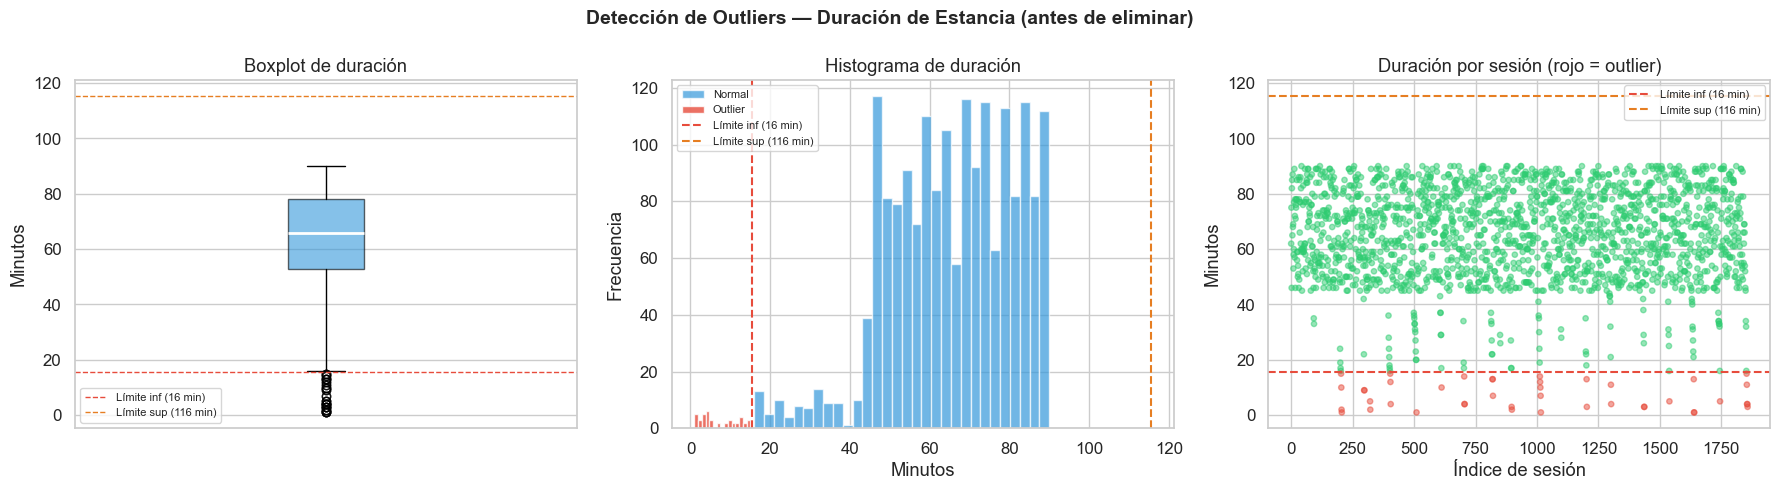


Outliers visualizados: 42 sesiones (2.3%)

=== Tratamiento aplicado ===
✅ Se eliminaron 84 registros (42 sesiones <16 min)
   Dataset: 3716 → 3632 registros

   Ocupación recalculada:
   → Máxima: 41 personas
   → Media:  16.6 personas


In [42]:
# 2.6  Análisis y tratamiento de outliers en duración de estancia

# Detectamos sesiones atípicas que podrían distorsionar el análisis de ocupación.
# Ejemplo: alguien que entra solo a ver qué hay y sale en 5 minutos no representa
# una sesión de entrenamiento real.

# Emparejar ingresos con salidas para calcular duración
ingresos_temp = df[df['accion'] == 'ingreso'][['student_id', 'fecha', 'timestamp']].copy()
ingresos_temp = ingresos_temp.rename(columns={'timestamp': 'ts_ingreso'})

salidas_temp = df[df['accion'] == 'salida'][['student_id', 'fecha', 'timestamp']].copy()
salidas_temp = salidas_temp.rename(columns={'timestamp': 'ts_salida'})

sesiones_temp = ingresos_temp.merge(salidas_temp, on=['student_id', 'fecha'], how='inner')
sesiones_temp['duracion_min'] = (sesiones_temp['ts_salida'] - sesiones_temp['ts_ingreso']).dt.total_seconds() / 60

# Estadísticas de duración
print('=== Estadísticas de duración de estancia ===')
print(f'Media:      {sesiones_temp["duracion_min"].mean():.1f} minutos')
print(f'Mediana:    {sesiones_temp["duracion_min"].median():.1f} minutos')
print(f'Q25:        {sesiones_temp["duracion_min"].quantile(0.25):.1f} minutos')
print(f'Q75:        {sesiones_temp["duracion_min"].quantile(0.75):.1f} minutos')
print(f'Desv. Std:  {sesiones_temp["duracion_min"].std():.1f} minutos')
print(f'Mínimo:     {sesiones_temp["duracion_min"].min():.1f} minutos')
print(f'Máximo:     {sesiones_temp["duracion_min"].max():.1f} minutos')

# Identificar outliers usando el método IQR
Q1 = sesiones_temp['duracion_min'].quantile(0.25)
Q3 = sesiones_temp['duracion_min'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = sesiones_temp[(sesiones_temp['duracion_min'] < limite_inferior) | 
                         (sesiones_temp['duracion_min'] > limite_superior)]

print(f'\n=== Detección de outliers (método IQR) ===')
print(f'Rango intercuartil (IQR): {IQR:.1f} minutos')
print(f'Límites normales:  [{max(0, limite_inferior):.0f}, {limite_superior:.0f}] minutos')
print(f'Outliers detectados: {len(outliers)} sesiones ({100*len(outliers)/len(sesiones_temp):.1f}%)')

# Desglose de outliers
outliers_cortos = sesiones_temp[sesiones_temp['duracion_min'] < 16]
outliers_largos = sesiones_temp[sesiones_temp['duracion_min'] > limite_superior]

print(f'\n  Sesiones muy cortas (<16 min): {len(outliers_cortos)}')
print(f'    → Interpretación: personas que entran a ver/consultar y salen rápido.')
print(f'    → No representan sesiones de entrenamiento reales.')
if len(outliers_cortos) > 0:
    print(f'    → Distribución: {outliers_cortos["duracion_min"].describe()[["min","mean","max"]].to_string()}')

print(f'\n  Sesiones muy largas (>{limite_superior:.0f} min): {len(outliers_largos)}')
if len(outliers_largos) > 0:
    for val in outliers_largos.nlargest(5, 'duracion_min')['duracion_min'].values:
        horas = int(val // 60)
        mins = int(val % 60)
        print(f'    → {horas}h {mins}min ({val:.0f} min)')

# ── VISUALIZACIÓN DE OUTLIERS (antes de eliminarlos) ──
es_outlier = (sesiones_temp['duracion_min'] < limite_inferior) | (sesiones_temp['duracion_min'] > limite_superior)
colores = es_outlier.map({True: '#e74c3c', False: '#2ecc71'})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Detección de Outliers — Duración de Estancia (antes de eliminar)', fontsize=14, fontweight='bold')

# Boxplot
ax1 = axes[0]
bp = ax1.boxplot(sesiones_temp['duracion_min'], vert=True, patch_artist=True,
                 flierprops=dict(marker='o', color='#e74c3c', markersize=6, alpha=0.7),
                 boxprops=dict(facecolor='#3498db', alpha=0.6),
                 medianprops=dict(color='white', linewidth=2))
ax1.set_title('Boxplot de duración')
ax1.set_ylabel('Minutos')
ax1.set_xticks([])
ax1.axhline(max(0, limite_inferior), color='#e74c3c', linestyle='--', linewidth=1, label=f'Límite inf ({max(0, limite_inferior):.0f} min)')
ax1.axhline(limite_superior, color='#e67e22', linestyle='--', linewidth=1, label=f'Límite sup ({limite_superior:.0f} min)')
ax1.legend(fontsize=8)

# Histograma con límites IQR
ax2 = axes[1]
ax2.hist(sesiones_temp.loc[~es_outlier, 'duracion_min'], bins=30, color='#3498db', alpha=0.7, label='Normal')
ax2.hist(sesiones_temp.loc[es_outlier, 'duracion_min'], bins=15, color='#e74c3c', alpha=0.8, label='Outlier')
ax2.axvline(max(0, limite_inferior), color='#e74c3c', linestyle='--', linewidth=1.5, label=f'Límite inf ({max(0, limite_inferior):.0f} min)')
ax2.axvline(limite_superior, color='#e67e22', linestyle='--', linewidth=1.5, label=f'Límite sup ({limite_superior:.0f} min)')
ax2.set_title('Histograma de duración')
ax2.set_xlabel('Minutos')
ax2.set_ylabel('Frecuencia')
ax2.legend(fontsize=8)

# Scatter duración por sesión
ax3 = axes[2]
ax3.scatter(range(len(sesiones_temp)), sesiones_temp['duracion_min'], c=colores, alpha=0.5, s=15)
ax3.axhline(max(0, limite_inferior), color='#e74c3c', linestyle='--', linewidth=1.5, label=f'Límite inf ({max(0, limite_inferior):.0f} min)')
ax3.axhline(limite_superior, color='#e67e22', linestyle='--', linewidth=1.5, label=f'Límite sup ({limite_superior:.0f} min)')
ax3.set_title('Duración por sesión (rojo = outlier)')
ax3.set_xlabel('Índice de sesión')
ax3.set_ylabel('Minutos')
ax3.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'\nOutliers visualizados: {es_outlier.sum()} sesiones ({100*es_outlier.mean():.1f}%)')

# ── TRATAMIENTO: Eliminar sesiones <16 min del dataset principal ──
# Estas visitas cortas inflan artificialmente la ocupación sin representar
# uso real del gimnasio. Sus pares ingreso-salida se eliminan de df.

ids_outliers_cortos = outliers_cortos[['student_id', 'fecha']].drop_duplicates()

n_antes = len(df)
# Marcar los registros a eliminar (tanto ingreso como salida del outlier)
df = df.merge(ids_outliers_cortos, on=['student_id', 'fecha'], how='left', indicator=True)
df = df[df['_merge'] == 'left_only'].drop(columns='_merge')

n_eliminados = n_antes - len(df)
print(f'\n=== Tratamiento aplicado ===')
print(f'✅ Se eliminaron {n_eliminados} registros ({n_eliminados//2} sesiones <16 min)')
print(f'   Dataset: {n_antes} → {len(df)} registros')

# Recalcular ocupación acumulada después de eliminar outliers
df = df.sort_values('timestamp').reset_index(drop=True)
df['ocupacion'] = df.groupby(df['fecha'].dt.date)['señal'].cumsum()

print(f'\n   Ocupación recalculada:')
print(f'   → Máxima: {df["ocupacion"].max()} personas')
print(f'   → Media:  {df["ocupacion"].mean():.1f} personas')

=== Verificación de continuidad de datos ===
Rango de fechas:  2026-03-30 a 2026-04-24
Total de días en el rango: 26
Días con registros: 21
Días sin registros: 5

📌 Domingos sin registros: 3
   → El gimnasio NO abre los domingos (operación normal)

🔴 FERIADOS DETECTADOS (2 días laborables sin registros):
   → 2026-04-02 (Jueves)
   → 2026-04-03 (Viernes)

   Estos días corresponden a feriados nacionales.
   → No se incluirán en el análisis de patrones regulares.

📊 Días con actividad inusualmente baja (<83 registros):
  → 2026-04-04 (Sábado): 44 registros
  → 2026-04-11 (Sábado): 60 registros
  → 2026-04-18 (Sábado): 50 registros


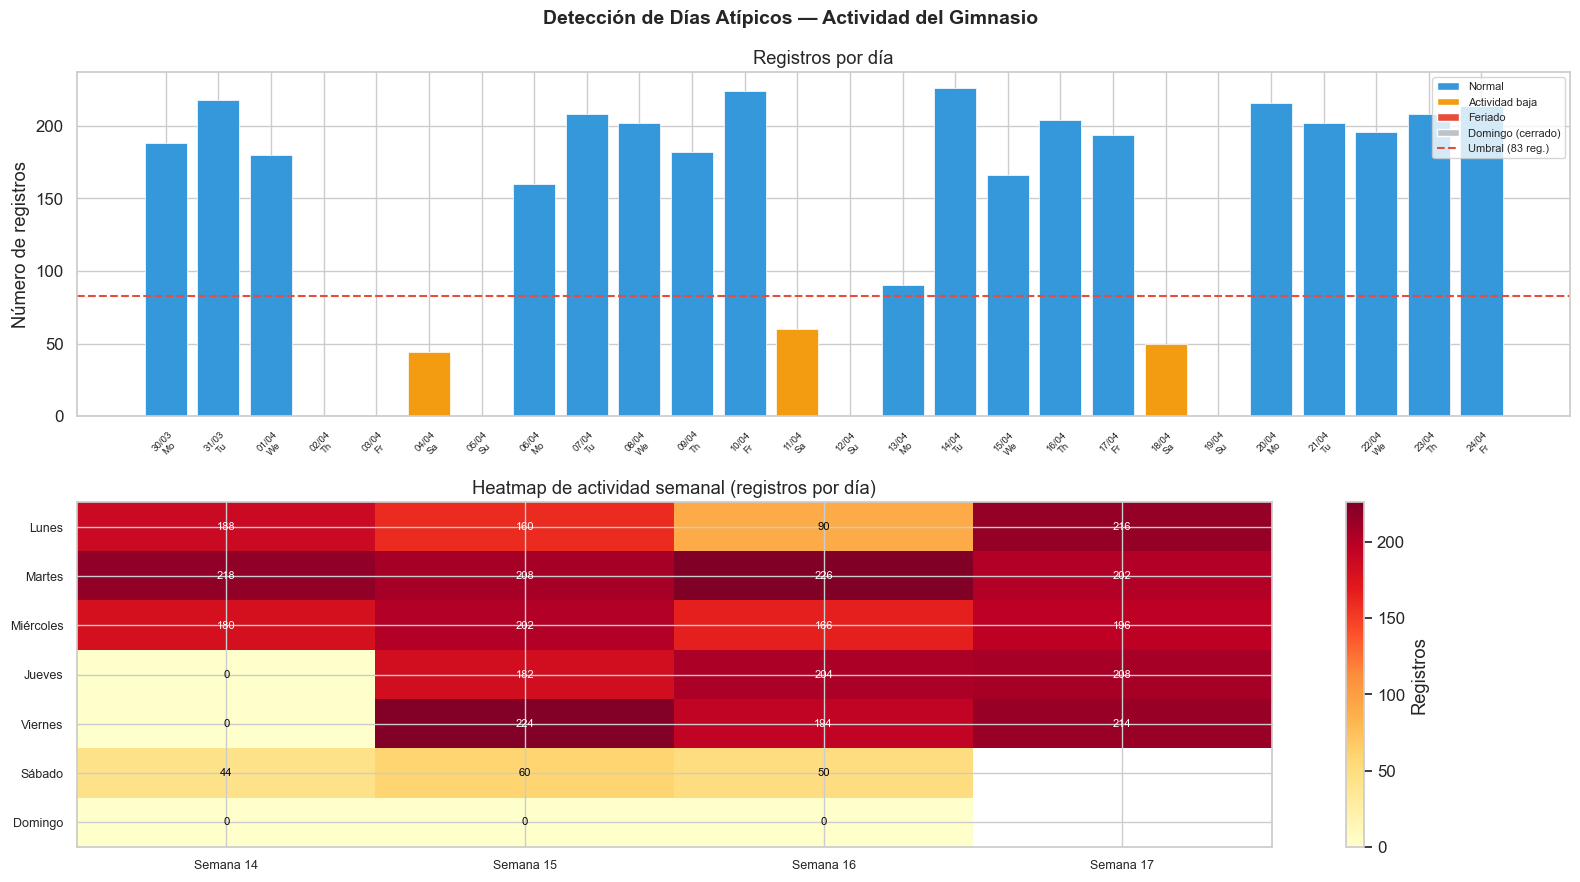

In [43]:
# 2.7  Verificación de días sin registros y tratamiento de feriados

# Detectar días sin registros para identificar cierres o feriados.

fecha_inicio = df['fecha'].min()
fecha_fin = df['fecha'].max()
rango_completo = pd.date_range(start=fecha_inicio, end=fecha_fin, freq='D')

dias_con_registros = pd.to_datetime(df['fecha'].dt.date.unique())
dias_sin_registros = rango_completo[~rango_completo.isin(dias_con_registros)]

print('=== Verificación de continuidad de datos ===')
print(f'Rango de fechas:  {fecha_inicio.date()} a {fecha_fin.date()}')
print(f'Total de días en el rango: {len(rango_completo)}')
print(f'Días con registros: {len(dias_con_registros)}')
print(f'Días sin registros: {len(dias_sin_registros)}')

dia_es_completo = {'Monday': 'Lunes', 'Tuesday': 'Martes', 'Wednesday': 'Miércoles',
                   'Thursday': 'Jueves', 'Friday': 'Viernes', 'Saturday': 'Sábado', 
                   'Sunday': 'Domingo'}

if len(dias_sin_registros) > 0:
    # Clasificar días sin registros
    domingos = [f for f in dias_sin_registros if f.day_name() == 'Sunday']
    feriados = [f for f in dias_sin_registros if f.day_name() not in ['Sunday', 'Saturday']]
    sabados_sin = [f for f in dias_sin_registros if f.day_name() == 'Saturday']
    
    if domingos:
        print(f'\n📌 Domingos sin registros: {len(domingos)}')
        print('   → El gimnasio NO abre los domingos (operación normal)')
    
    if feriados:
        print(f'\n🔴 FERIADOS DETECTADOS ({len(feriados)} días laborables sin registros):')
        for fecha in feriados:
            print(f'   → {fecha.date()} ({dia_es_completo[fecha.day_name()]})')
        
        print('\n   Estos días corresponden a feriados nacionales.')
        print('   → No se incluirán en el análisis de patrones regulares.')
    
    if sabados_sin:
        print(f'\n⚠️  Sábados sin registros: {len(sabados_sin)}')
        for fecha in sabados_sin:
            print(f'   → {fecha.date()}')

# Verificar días con actividad inusualmente baja
registros_por_dia = df.groupby(df['fecha'].dt.date).size()
umbral_bajo = registros_por_dia.quantile(0.25) * 0.5

dias_con_pocos_registros = registros_por_dia[registros_por_dia < umbral_bajo]
if len(dias_con_pocos_registros) > 0:
    print(f'\n📊 Días con actividad inusualmente baja (<{umbral_bajo:.0f} registros):')
    for fecha, n_reg in dias_con_pocos_registros.items():
        fecha_dt = pd.to_datetime(fecha)
        print(f'  → {fecha} ({dia_es_completo.get(fecha_dt.day_name(), fecha_dt.day_name())}): {n_reg} registros')
else:
    print('\n✅ No hay días con actividad inusualmente baja.')

# ── VISUALIZACIÓN DE DÍAS ATÍPICOS ──
registros_por_dia_viz = df.groupby(df['fecha'].dt.date).size().reset_index()
registros_por_dia_viz.columns = ['fecha', 'n_registros']
registros_por_dia_viz['fecha'] = pd.to_datetime(registros_por_dia_viz['fecha'])

rango_viz = pd.date_range(start=registros_por_dia_viz['fecha'].min(),
                          end=registros_por_dia_viz['fecha'].max(), freq='D')
rango_df = pd.DataFrame({'fecha': rango_viz})
rango_df = rango_df.merge(registros_por_dia_viz, on='fecha', how='left').fillna(0)
rango_df['n_registros'] = rango_df['n_registros'].astype(int)

umbral_viz = registros_por_dia_viz['n_registros'].quantile(0.25) * 0.5

def clasificar_dia(row):
    if row['n_registros'] == 0 and row['fecha'].day_name() == 'Sunday':
        return 'Domingo (cerrado)'
    elif row['n_registros'] == 0:
        return 'Feriado'
    elif row['n_registros'] < umbral_viz:
        return 'Actividad baja'
    else:
        return 'Normal'

rango_df['tipo'] = rango_df.apply(clasificar_dia, axis=1)

color_map = {'Normal': '#3498db', 'Actividad baja': '#f39c12', 'Feriado': '#e74c3c', 'Domingo (cerrado)': '#bdc3c7'}
bar_colors = rango_df['tipo'].map(color_map)

fig, axes = plt.subplots(2, 1, figsize=(16, 9))
fig.suptitle('Detección de Días Atípicos — Actividad del Gimnasio', fontsize=14, fontweight='bold')

# Barras de registros por día
ax1 = axes[0]
ax1.bar(range(len(rango_df)), rango_df['n_registros'], color=bar_colors, edgecolor='white', linewidth=0.5)
ax1.axhline(umbral_viz, color='#e74c3c', linestyle='--', linewidth=1.5, label=f'Umbral baja actividad ({umbral_viz:.0f} reg.)')
ax1.set_xticks(range(len(rango_df)))
ax1.set_xticklabels([f.strftime('%d/%m\n%a')[:8] for f in rango_df['fecha']], fontsize=7, rotation=45)
ax1.set_ylabel('Número de registros')
ax1.set_title('Registros por día')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in color_map.items()]
legend_elements.append(plt.Line2D([0], [0], color='#e74c3c', linestyle='--', label=f'Umbral ({umbral_viz:.0f} reg.)'))
ax1.legend(handles=legend_elements, fontsize=8, loc='upper right')

# Heatmap semanal
ax2 = axes[1]
dias_semana_orden = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dias_semana_es = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

rango_df['semana'] = rango_df['fecha'].dt.isocalendar().week.astype(int)
rango_df['dia_nombre_en'] = rango_df['fecha'].dt.day_name()

semanas = sorted(rango_df['semana'].unique())
heatmap_data = rango_df.pivot_table(index='dia_nombre_en', columns='semana', values='n_registros', aggfunc='sum').reindex(dias_semana_orden)

im = ax2.imshow(heatmap_data.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')
ax2.set_xticks(range(len(semanas)))
ax2.set_xticklabels([f'Semana {s}' for s in semanas], fontsize=9)
ax2.set_yticks(range(len(dias_semana_es)))
ax2.set_yticklabels(dias_semana_es, fontsize=9)
ax2.set_title('Heatmap de actividad semanal (registros por día)')

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        val = heatmap_data.values[i, j]
        if not pd.isna(val):
            ax2.text(j, i, f'{int(val)}', ha='center', va='center', fontsize=8,
                     color='white' if val > heatmap_data.values[~pd.isna(heatmap_data.values)].max() * 0.6 else 'black')

plt.colorbar(im, ax=ax2, label='Registros')
plt.tight_layout()
plt.show()

#### Decisiones de preprocesamiento — Justificación

| Decisión | Justificación | Alternativa descartada |
|----------|---------------|------------------------|
| **Timestamp = fecha + hora** | Permite ordenar cronológicamente y calcular ocupación acumulada | Mantener fecha y hora separadas impediría cálculos de series temporales |
| **Cumsum por día, no global** | El gimnasio se vacía cada noche; una cumsum global arrastraría error | Cumsum global generaría ocupaciones artificialmente altas |
| **No se eliminan registros duplicados** | No hay duplicados, nulos ni inconsistencias | Filtramos solo si detectábamos problemas |
| **Señal +1/-1** | Representación estándar para modelar flujo neto | Contar ingresos y salidas por separado sería más complejo sin beneficio |
| **Eliminar sesiones <16 min** | Son visitas rápidas (entrar a ver/consultar), no entrenamiento real; inflan la ocupación sin representar uso del gimnasio | Mantenerlas distorsionaría las métricas de ocupación y duración promedio |
| **Feriados identificados** | Los jueves y viernes sin registros son feriados nacionales; excluirlos evita distorsionar patrones regulares | Incluirlos como "días sin demanda" sesgaría promedios semanales a la baja |

## 3. Feature Engineering

### ¿Qué es Feature Engineering y por qué es necesario aquí?

Feature Engineering es el proceso de **transformar datos crudos en variables informativas** que un modelo predictivo pueda aprovechar. En nuestro caso, el dataset original contiene timestamps de ingreso/salida, pero un modelo no puede aprender patrones directamente de un datetime. Necesitamos descomponerlo en componentes que representen los ciclos reales de comportamiento del gimnasio.

### Proceso paso a paso

El Feature Engineering de este proyecto se divide en 4 pasos secuenciales, cada uno con una justificación basada en los datos observados:

| Paso | Variable(s) creada(s) | Tipo | Justificación basada en datos |
|------|----------------------|------|-------------------------------|
| **3.1** | `hora_num` | int (0–23) | Los datos muestran que la ocupación varía drásticamente entre horas: de ~4 personas a las 9am a ~29 a las 12pm. Sin esta variable, el modelo no puede capturar el patrón intradiario. |
| **3.1** | `dia_semana` | int (0–6) | Los sábados registran ~50 eventos vs ~180+ entre semana. El día de la semana es un predictor fuerte de la demanda. |
| **3.1** | `dia_nombre` | str | Versión legible de `dia_semana` para facilitar visualizaciones y validación humana. No se usa como feature del modelo. |
| **3.1** | `es_fin_de_semana` | binario (0/1) | Simplifica la distinción laboral/descanso. Los sábados tienen un comportamiento tan diferente que un solo flag binario ya aporta información predictiva significativa. |
| **3.1** | `mes` | int (1–12) | Aunque solo tenemos marzo y abril, esta variable prepara el pipeline para cuando se agreguen más meses. La estacionalidad académica (parciales, finales, vacaciones) se capturará aquí. |
| **3.2** | `bloque_horario` | categórico (Mañana/Tarde) | Los datos muestran dos regímenes claros: baja ocupación antes de las 12pm (~694 registros) y alta ocupación después (~2938 registros). Este feature reduce dimensionalidad y captura cómo los estudiantes planifican (\"voy en la mañana\" vs \"voy en la tarde\"). |
| **3.3** | `ocupacion_max` | int | Ocupación pico alcanzada en cada hora de cada día. Es la variable objetivo principal para predicción: \"¿cuántas personas habrá como máximo a las 12pm del lunes?\". |
| **3.3** | `ocupacion_media` | float | Promedio de ocupación dentro de cada hora. Complementa al máximo para entender la carga sostenida, no solo el pico. |
| **3.3** | `n_ingresos` | int | Cantidad de personas que entraron en esa hora. Mide el flujo de entrada, útil para detectar \"olas\" de llegada. |

### ¿Cómo se agregan estas variables?

1. **Extracción directa del timestamp** (3.1): Se usan los métodos `.dt.hour`, `.dt.dayofweek`, `.dt.month` de pandas para descomponer el datetime en sus componentes numéricos. Esto no pierde información; solo la hace accesible al modelo.

2. **Transformación categórica** (3.2): Se aplica una función que mapea la hora numérica a un bloque semántico. Esto agrupa horas con comportamiento similar y reduce la cardinalidad de 10 horas posibles a 2 bloques.

3. **Agregación temporal** (3.3): Se agrupa el dataset por (fecha, hora) y se calculan estadísticos de ocupación. Esto transforma el dataset de eventos individuales (~3632 filas) a una serie temporal regular (~173 filas) que un modelo de series temporales puede consumir directamente.

### Criterio de selección de variables

Cada variable fue incluida solo si cumple al menos uno de estos criterios:
- **Evidencia en los datos**: los datos muestran variación significativa al segmentar por esa variable.
- **Relevancia para el negocio**: la variable responde a una pregunta que el usuario del gimnasio haría (\"¿a qué hora hay menos gente?\").
- **Escalabilidad**: la variable será más útil cuando se tenga más data histórica.

### 3.1 Extracción de componentes temporales

Descomponemos el timestamp en variables numéricas que el modelo pueda usar como features. Cada componente captura un ciclo diferente de comportamiento:

- `hora_num`: ciclo intradiario (la ocupación cambia hora a hora).
- `dia_semana` + `dia_nombre`: ciclo semanal (lunes ≠ sábado).
- `es_fin_de_semana`: simplificación binaria del ciclo semanal.
- `mes`: ciclo mensual/académico (preparado para datos futuros).

In [44]:
# 3.1  Extraer componentes temporales

# Hora del día (entero 0-23)
# → Feature clave para predecir ocupación: captura el patrón intradiario
df['hora_num'] = df['timestamp'].dt.hour

# Día de la semana (0=Lunes, 6=Domingo)
# → Captura patrones semanales: el comportamiento del gym varía mucho entre días
df['dia_semana'] = df['timestamp'].dt.dayofweek
df['dia_nombre'] = df['timestamp'].dt.day_name()

# ¿Es fin de semana? (Sábado o Domingo)
# → Feature binario útil: la demanda de sábado es mucho menor que entre semana
df['es_fin_de_semana'] = df['dia_semana'].isin([5, 6]).astype(int)

# Mes
# → Aunque solo tenemos marzo-abril, este feature escala si se agrega más data
df['mes'] = df['timestamp'].dt.month

print('Features temporales creados:')
print(df[['timestamp', 'hora_num', 'dia_semana', 'dia_nombre', 'es_fin_de_semana', 'mes']].head(8).to_string())

Features temporales creados:
            timestamp  hora_num  dia_semana dia_nombre  es_fin_de_semana  mes
0 2026-03-30 09:14:00         9           0     Monday                 0    3
1 2026-03-30 09:22:00         9           0     Monday                 0    3
2 2026-03-30 09:26:00         9           0     Monday                 0    3
3 2026-03-30 09:58:00         9           0     Monday                 0    3
4 2026-03-30 10:00:00        10           0     Monday                 0    3
5 2026-03-30 10:02:00        10           0     Monday                 0    3
6 2026-03-30 10:12:00        10           0     Monday                 0    3
7 2026-03-30 10:16:00        10           0     Monday                 0    3


### 3.2 Bloque horario (reducción de dimensionalidad)

Los datos muestran dos regímenes de ocupación claramente diferenciados:
- **Mañana (antes de 12pm)**: ~694 registros, ocupación baja y estable.
- **Tarde (12pm en adelante)**: ~2938 registros, ocupación alta con picos pronunciados.

En lugar de usar las 10 horas individuales como categorías, agrupamos en 2 bloques. Esto:
- Reduce la cardinalidad sin perder el patrón principal.
- Refleja cómo los estudiantes realmente planifican: \"voy en la mañana\" o \"voy en la tarde\".
- Facilita la segmentación en análisis posteriores.

In [45]:
# 3.2  Bloque horario

# Agrupamos las horas en bloques semánticos:
#   Mañana:  Hasta 11:59
#   Tarde:   12:00 en adelante
#
# Nota: El gimnasio abre L-V de 9am-6pm y Sáb de 8am-1pm
#
# ¿Por qué? Los estudiantes no planifican al minuto; piensan
# en "ir en la mañana" o "ir en la tarde". Este feature captura
# esa granularidad de decisión y reduce la dimensionalidad.

def asignar_bloque(hora):
    if hora < 12:
        return 'Mañana'
    else:
        return 'Tarde'

df['bloque_horario'] = df['hora_num'].apply(asignar_bloque)

print('Distribución por bloque horario:')
print(df['bloque_horario'].value_counts().to_string())

Distribución por bloque horario:
bloque_horario
Tarde     2938
Mañana     694


### 3.3 Tabla de ocupación agregada por hora

Hasta ahora, cada fila del dataset es un evento individual (un ingreso o una salida). Para análisis y modelado, necesitamos una **serie temporal regular** donde cada fila represente un intervalo de tiempo fijo.

Agregamos por (fecha, hora) y calculamos:
- `ocupacion_max`: el pico de personas en esa hora. Es la variable objetivo para responder \"¿cuánta gente habrá como máximo?\".
- `ocupacion_media`: la carga promedio sostenida. Útil para dimensionar recursos (ej: toallas, equipos).
- `n_ingresos`: flujo de entrada. Detecta \"olas\" de llegada que el máximo solo no captura.

¿Por qué granularidad horaria? Es un balance entre:
- **Minuto a minuto**: demasiado ruido, pocos eventos por intervalo → métricas inestables.
- **Bloques de 4 horas**: pierde los picos intradiarios que son clave para recomendar horarios.

El resultado es un dataset de ~173 filas (21 días × ~8 horas/día) listo para modelado.

In [46]:
# 3.3  Crear tabla de ocupación agregada por hora

# Para el análisis descriptivo y para alimentar un modelo predictivo,
# necesitamos una serie temporal con granularidad uniforme.
#
# Pasos:
#   1. Para cada día, obtenemos la ocupación al final de cada hora.
#   2. Esto nos da un valor de ocupación por cada par (fecha, hora).
#
# ¿Por qué por hora? Es un balance entre:
#   - Muy fino (minuto): demasiado ruido, pocos eventos por intervalo.
#   - Muy grueso (bloque 4h): pierde patrones intradiarios.

# Obtener la ocupación máxima alcanzada en cada hora de cada día
ocupacion_hora = (
    df[df['accion'] == 'ingreso']  # Nos centramos en ingresos para no duplicar
    .groupby([df['fecha'].dt.date, 'hora_num'])
    .agg(ocupacion_max=('ocupacion', 'max'),
         ocupacion_media=('ocupacion', 'mean'),
         n_ingresos=('señal', 'sum'))
    .reset_index()
    .rename(columns={'fecha': 'fecha_date'})
)

# Re-crear features temporales en la tabla agregada
ocupacion_hora['fecha_date'] = pd.to_datetime(ocupacion_hora['fecha_date'])
ocupacion_hora['dia_semana'] = ocupacion_hora['fecha_date'].dt.dayofweek
ocupacion_hora['dia_nombre'] = ocupacion_hora['fecha_date'].dt.day_name()
ocupacion_hora['es_fin_de_semana'] = ocupacion_hora['dia_semana'].isin([5, 6]).astype(int)
ocupacion_hora['bloque_horario'] = ocupacion_hora['hora_num'].apply(asignar_bloque)
ocupacion_hora['mes'] = ocupacion_hora['fecha_date'].dt.month

print(f'Tabla de ocupación por hora: {ocupacion_hora.shape[0]} registros')
print(f'Rango de horas observadas: {ocupacion_hora["hora_num"].min()}:00 – {ocupacion_hora["hora_num"].max()}:00')
ocupacion_hora.head(10)

Tabla de ocupación por hora: 173 registros
Rango de horas observadas: 8:00 – 17:00


,fecha_date,hora_num,ocupacion_max,ocupacion_media,n_ingresos,dia_semana,dia_nombre,es_fin_de_semana,bloque_horario,mes
0,2026-03-30,9,4,2.500000,4,0,Monday,0,Mañana,3
1,2026-03-30,10,8,6.285714,7,0,Monday,0,Mañana,3
2,2026-03-30,11,12,11.000000,8,0,Monday,0,Mañana,3
3,2026-03-30,12,29,18.931034,29,0,Monday,0,Tarde,3
4,2026-03-30,13,33,30.043478,23,0,Monday,0,Tarde,3
5,2026-03-30,14,26,20.750000,4,0,Monday,0,Tarde,3
6,2026-03-30,15,8,6.714286,7,0,Monday,0,Tarde,3
7,2026-03-30,16,12,9.750000,8,0,Monday,0,Tarde,3
8,2026-03-30,17,9,8.750000,4,0,Monday,0,Tarde,3
9,2026-03-31,9,6,3.500000,6,1,Tuesday,0,Mañana,3


### 3.4 Vista final del dataset procesado

Verificamos que el Feature Engineering produjo dos datasets listos para análisis:
- `df` (eventos): 3632 filas × 17 columnas — cada fila es un ingreso o salida individual con todos los features temporales.
- `ocupacion_hora` (agregado): ~173 filas × 10 columnas — serie temporal horaria con métricas de ocupación.

El dataset agregado es el que alimentará el modelo predictivo; el de eventos se usa para análisis demográfico y de duración.

In [47]:
# 3.4  Vista final del dataset procesado


print('=== Columnas del dataset de eventos (df) ===')
print(df.columns.tolist())
print(f'Shape: {df.shape}')
print()
print('=== Columnas del dataset agregado por hora (ocupacion_hora) ===')
print(ocupacion_hora.columns.tolist())
print(f'Shape: {ocupacion_hora.shape}')
print()
print('Tipos de datos del dataset procesado:')
print(df.dtypes)

=== Columnas del dataset de eventos (df) ===
['student_id', 'facultad', 'carrera', 'genero', 'fecha', 'hora', 'accion', 'hora_td', 'timestamp', 'señal', 'ocupacion', 'hora_num', 'dia_semana', 'dia_nombre', 'es_fin_de_semana', 'mes', 'bloque_horario']
Shape: (3632, 17)

=== Columnas del dataset agregado por hora (ocupacion_hora) ===
['fecha_date', 'hora_num', 'ocupacion_max', 'ocupacion_media', 'n_ingresos', 'dia_semana', 'dia_nombre', 'es_fin_de_semana', 'bloque_horario', 'mes']
Shape: (173, 10)

Tipos de datos del dataset procesado:
student_id                      str
facultad                        str
carrera                         str
genero                          str
fecha                datetime64[us]
hora                            str
accion                          str
hora_td             timedelta64[us]
timestamp            datetime64[us]
señal                         int64
ocupacion                     int64
hora_num                      int32
dia_semana                  


## 4. Retos y Limitaciones de los Datos

Antes de analizar, es **crítico** reconocer las limitaciones del dataset. Ignorarlas llevaría a conclusiones falsamente robustas y a un modelo sobreconfiado.

### 4.1  Ventana temporal corta (23 días)

- Solo tenemos datos del **30 de marzo al 24 de abril de 2026** (~3.3 semanas).
- **Impacto en el modelo**: No podemos capturar estacionalidad mensual (parciales, finales, vacaciones, inicio de ciclo). Un modelo entrenado solo con estos datos podría generalizar mal a otros meses.
- **Mitigación**: Documentar que el modelo requiere datos de al menos un ciclo académico completo para producción.

### 4.2  Variables externas no disponibles

Factores que influyen en la ocupación del gym pero **no están en los datos**:

| Variable faltante | Efecto esperado | Posible fuente |
|-------------------|-----------------|----------------|
| **Clima** (lluvia, frío) | Reduce asistencia | API meteorológica |
| **Calendario académico** (exámenes, feriados) | Los parciales reducen uso; inicio de ciclo lo aumenta | Calendario UTEC |
| **Eventos especiales** (torneos, ferias) | Picos o valles atípicos | Calendar institucional |

→ **Impacto**: El modelo explicará parte de la varianza pero no toda. Las variables externas serían features poderosas en una versión 2.0.

### 4.3  Sesgo de representación

- **Ingeniería** domina el dataset (69%). Esto puede reflejar la composición real de UTEC o un sesgo de muestreo.
- **Género**: 63% masculino. Los patrones observados estarán "pesados" hacia el comportamiento masculino.
- **Impacto en recomendaciones**: Si recomendamos horarios basados en datos sesgados, podríamos no atender bien a segmentos minoritarios.

### 4.4  Granularidad del dato

- Tenemos timestamps exactos (al minuto), lo cual es bueno.
- Sin embargo, no sabemos **qué actividad** realiza el estudiante, ni **duración planeada**.
- La duración de estancia se puede inferir (ingreso → salida), pero no la intención.

### 4.5  Logs balanceados — ¿Demasiado perfectos?

- El hecho de que 100% de los estudiantes tengan balance perfecto (ingreso = salida) sugiere un sistema de control riguroso o datos sintéticos/preprocesados.
- En producción, siempre habrá logs incompletos (e.g., lector falla, persona sale por otra puerta).
- **Impacto**: El modelo entrenado con datos perfectos puede no ser robusto frente a datos ruidosos reales.


## 5. Análisis Descriptivo

Para guiar el análisis, planteamos **3 preguntas principales**, cada una con **2 subpreguntas** que se responden con visualizaciones y estadísticas concretas.

**P1**  ¿Cómo varía la ocupación del gimnasio según el momento del día y de la semana?
- **1.1** ¿Cuáles son las horas con mayor y menor ocupación? 
- **1.2** ¿Existen diferencias significativas entre días de la semana? 


**P2**  ¿Cómo influyen las características demográficas del estudiante en los patrones de uso?
- **2.1** ¿Hay diferencias en los patrones de asistencia entre géneros?
- **2.2** ¿Qué facultades y carreras lideran el uso del gimnasio?


**P3**  ¿Cuáles son las tendencias de la demanda y las características de las sesiones de entrenamiento?
- **3.1** ¿La demanda muestra tendencia o estabilidad durante el periodo?
- **3.2** ¿Cuánto tiempo permanecen los estudiantes y en qué bloques horarios prefieren asistir?


### Pregunta 1: ¿Cómo varía la ocupación del gimnasio según el momento del día y de la semana?

Esta pregunta es la más directamente conectada con el objetivo de GymTEC: para recomendar horarios óptimos, primero debemos entender **cuándo** se llena y **cuándo** se vacía el gimnasio.

#### Subpregunta 1.1: ¿Cuáles son las horas del día con mayor y menor ocupación?

Primero exploramos la distribución general de la ocupación para conocer los niveles típicos, y luego desagregamos por hora para identificar las **horas pico** y **horas valle**.

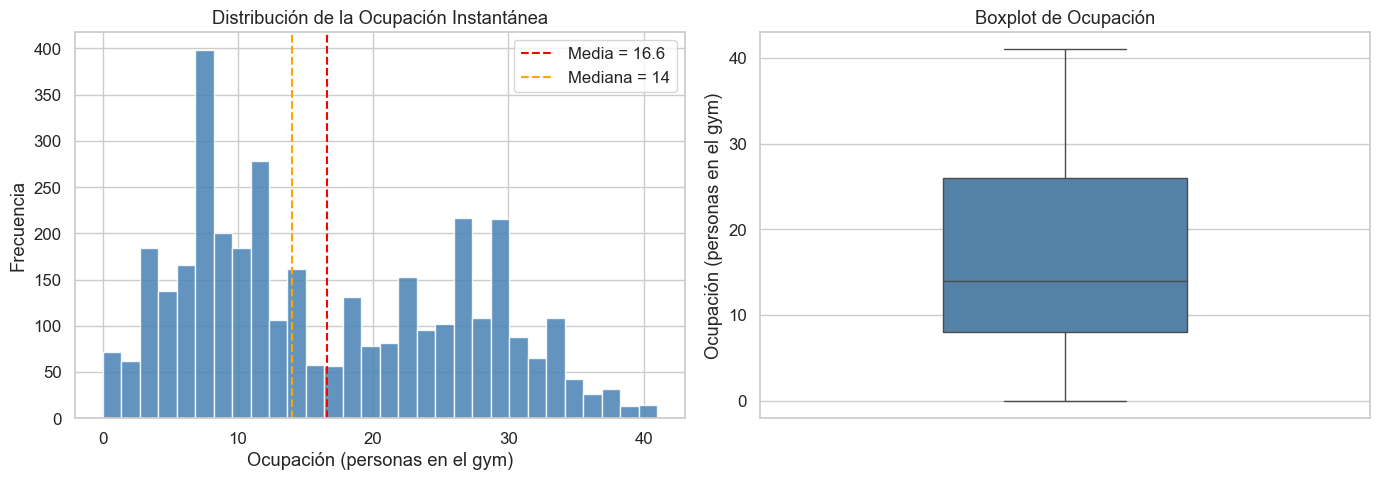

=== Estadísticas de ocupación ===
  Media:     16.6
  Mediana:   14
  Desv. Std: 10.1
  Mínimo:    0
  Máximo:    41
  Q25:       8
  Q75:       26


In [48]:
# 5.1  Distribución de la ocupación (histograma + boxplot)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df['ocupacion'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['ocupacion'].mean(), color='red', linestyle='--', label=f'Media = {df["ocupacion"].mean():.1f}')
axes[0].axvline(df['ocupacion'].median(), color='orange', linestyle='--', label=f'Mediana = {df["ocupacion"].median():.0f}')
axes[0].set_xlabel('Ocupación (personas en el gym)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de la Ocupación Instantánea')
axes[0].legend()

# Boxplot
sns.boxplot(y=df['ocupacion'], ax=axes[1], color='steelblue', width=0.4)
axes[1].set_ylabel('Ocupación (personas en el gym)')
axes[1].set_title('Boxplot de Ocupación')

plt.tight_layout()
plt.show()

# Estadísticas clave
print('=== Estadísticas de ocupación ===')
print(f'  Media:     {df["ocupacion"].mean():.1f}')
print(f'  Mediana:   {df["ocupacion"].median():.0f}')
print(f'  Desv. Std: {df["ocupacion"].std():.1f}')
print(f'  Mínimo:    {df["ocupacion"].min()}')
print(f'  Máximo:    {df["ocupacion"].max()}')
print(f'  Q25:       {df["ocupacion"].quantile(0.25):.0f}')
print(f'  Q75:       {df["ocupacion"].quantile(0.75):.0f}')

La distribución muestra los niveles típicos de ocupación. Ahora veamos cómo se distribuye esa ocupación **hora por hora** para identificar picos y valles.

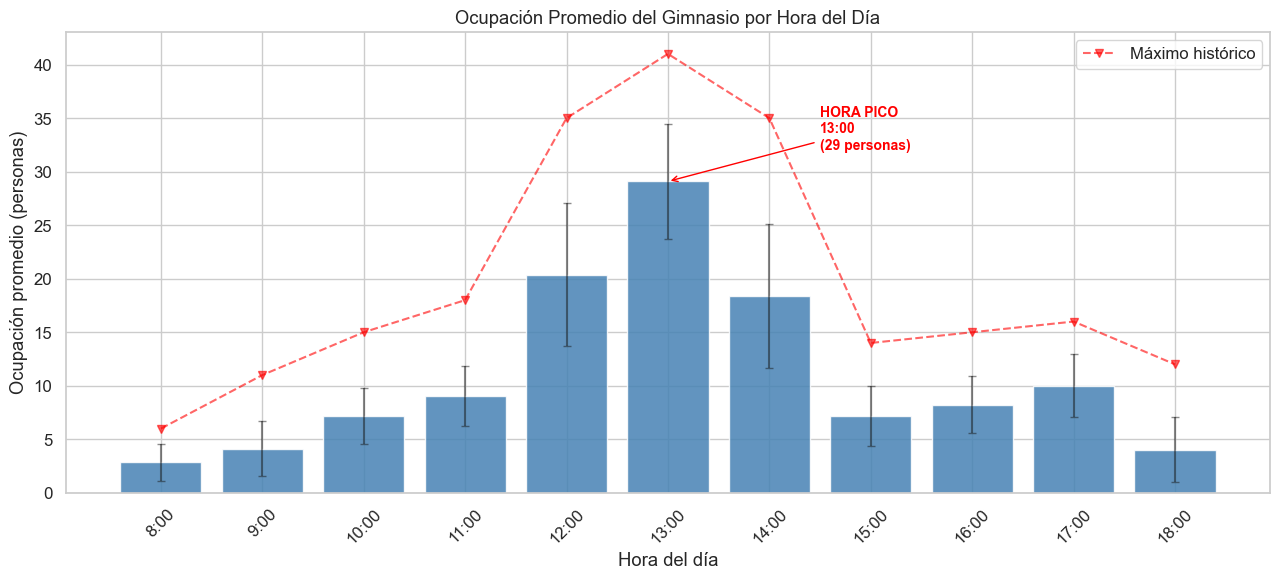


=== Top 5 horas con mayor ocupación promedio ===
  13:00 → Promedio: 29.1  |  Máximo: 41  |  Variabilidad: ±5.4
  12:00 → Promedio: 20.4  |  Máximo: 35  |  Variabilidad: ±6.7
  14:00 → Promedio: 18.4  |  Máximo: 35  |  Variabilidad: ±6.7
  17:00 → Promedio: 10.0  |  Máximo: 16  |  Variabilidad: ±2.9
  11:00 → Promedio: 9.0  |  Máximo: 18  |  Variabilidad: ±2.8


In [49]:
# 5.2  Ocupación promedio por hora

ocu_por_hora = df.groupby('hora_num')['ocupacion'].agg(['mean', 'std', 'max']).reset_index()
ocu_por_hora.columns = ['Hora', 'Media', 'Desv_Std', 'Máximo']

fig, ax = plt.subplots(figsize=(13, 6))

# Gráfico de barras con barras de error
bars = ax.bar(ocu_por_hora['Hora'], ocu_por_hora['Media'],
              color='steelblue', edgecolor='white', alpha=0.85,
              yerr=ocu_por_hora['Desv_Std'], capsize=3, error_kw={'alpha': 0.5})

# Línea del máximo histórico
ax.plot(ocu_por_hora['Hora'], ocu_por_hora['Máximo'],
        color='red', marker='v', linestyle='--', alpha=0.6, label='Máximo histórico')

# Anotar hora pico
hora_pico = ocu_por_hora.loc[ocu_por_hora['Media'].idxmax()]
ax.annotate(f'HORA PICO\n{int(hora_pico["Hora"])}:00\n({hora_pico["Media"]:.0f} personas)',
            xy=(hora_pico['Hora'], hora_pico['Media']),
            xytext=(hora_pico['Hora'] + 1.5, hora_pico['Media'] + 3),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red', fontweight='bold')

ax.set_xlabel('Hora del día')
ax.set_ylabel('Ocupación promedio (personas)')
ax.set_title('Ocupación Promedio del Gimnasio por Hora del Día')
ax.set_xticks(ocu_por_hora['Hora'])
ax.set_xticklabels([f'{int(h)}:00' for h in ocu_por_hora['Hora']], rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

# Tabla resumen
print('\n=== Top 5 horas con mayor ocupación promedio ===')
top5 = ocu_por_hora.sort_values('Media', ascending=False).head(5)
for _, row in top5.iterrows():
    print(f'  {int(row["Hora"]):02d}:00 → Promedio: {row["Media"]:.1f}  |  Máximo: {row["Máximo"]:.0f}  |  Variabilidad: ±{row["Desv_Std"]:.1f}')

**Respuesta a SP 1.1**: Existe un **patrón intradiario claro**, con horas pico bien definidas y horas valle (primeras horas de la mañana y últimas de la noche) con baja ocupación. La variable `hora_num` será con alta probabilidad el feature más importante para el modelo predictivo de GymTEC, ya que captura esta estacionalidad diaria. Las barras de error muestran la variabilidad: horas con alta variabilidad son menos predecibles.

---

#### Subpregunta 1.2: ¿Existen diferencias significativas en la demanda entre días de la semana?

Analizamos si la ocupación varía según el día, comparando entre semana vs. fin de semana, y luego cruzamos día × hora en un heatmap para identificar los **slots horarios exactos** de alta y baja demanda.

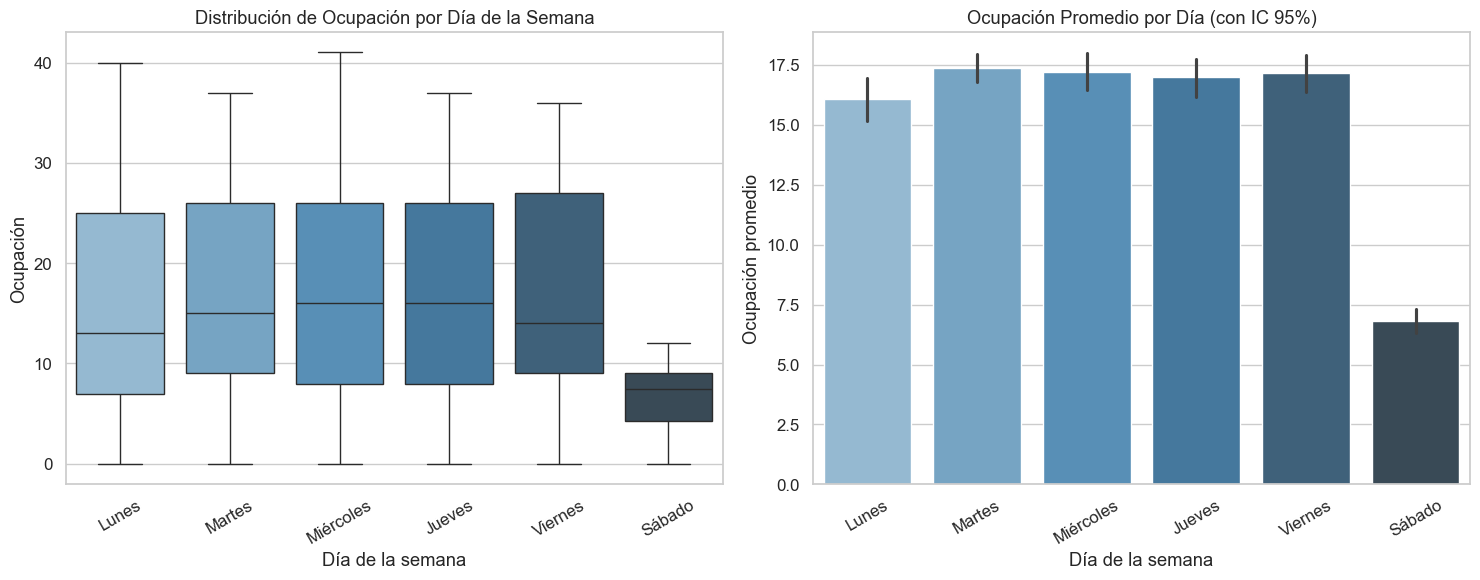


=== Total de ingresos por día de la semana ===
  Lunes       :  327 ingresos
  Martes      :  427 ingresos
  Miércoles   :  372 ingresos
  Jueves      :  297 ingresos
  Viernes     :  316 ingresos
  Sábado      :   77 ingresos


In [50]:
# 5.3  Ocupación por día de la semana

# Orden correcto de los días (lunes a sábado)
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
dia_es = {'Monday': 'Lunes', 'Tuesday': 'Martes', 'Wednesday': 'Miércoles',
          'Thursday': 'Jueves', 'Friday': 'Viernes', 'Saturday': 'Sábado'}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot: muestra la distribución completa por día
sns.boxplot(data=df, x='dia_nombre', y='ocupacion', order=orden_dias,
            palette='Blues_d', ax=axes[0])
axes[0].set_xticklabels([dia_es[d] for d in orden_dias], rotation=30)
axes[0].set_xlabel('Día de la semana')
axes[0].set_ylabel('Ocupación')
axes[0].set_title('Distribución de Ocupación por Día de la Semana')

# Barplot: ocupación promedio con intervalos de confianza
sns.barplot(data=df, x='dia_nombre', y='ocupacion', order=orden_dias,
            palette='Blues_d', ci=95, ax=axes[1])
axes[1].set_xticklabels([dia_es[d] for d in orden_dias], rotation=30)
axes[1].set_xlabel('Día de la semana')
axes[1].set_ylabel('Ocupación promedio')
axes[1].set_title('Ocupación Promedio por Día (con IC 95%)')

plt.tight_layout()
plt.show()

# Total de ingresos por día
ingresos_dia = df[df['accion'] == 'ingreso'].groupby('dia_nombre').size()
ingresos_dia = ingresos_dia.reindex(orden_dias)
print('\n=== Total de ingresos por día de la semana ===')
for d in orden_dias:
    print(f'  {dia_es[d]:12s}: {ingresos_dia.get(d, 0):4d} ingresos')

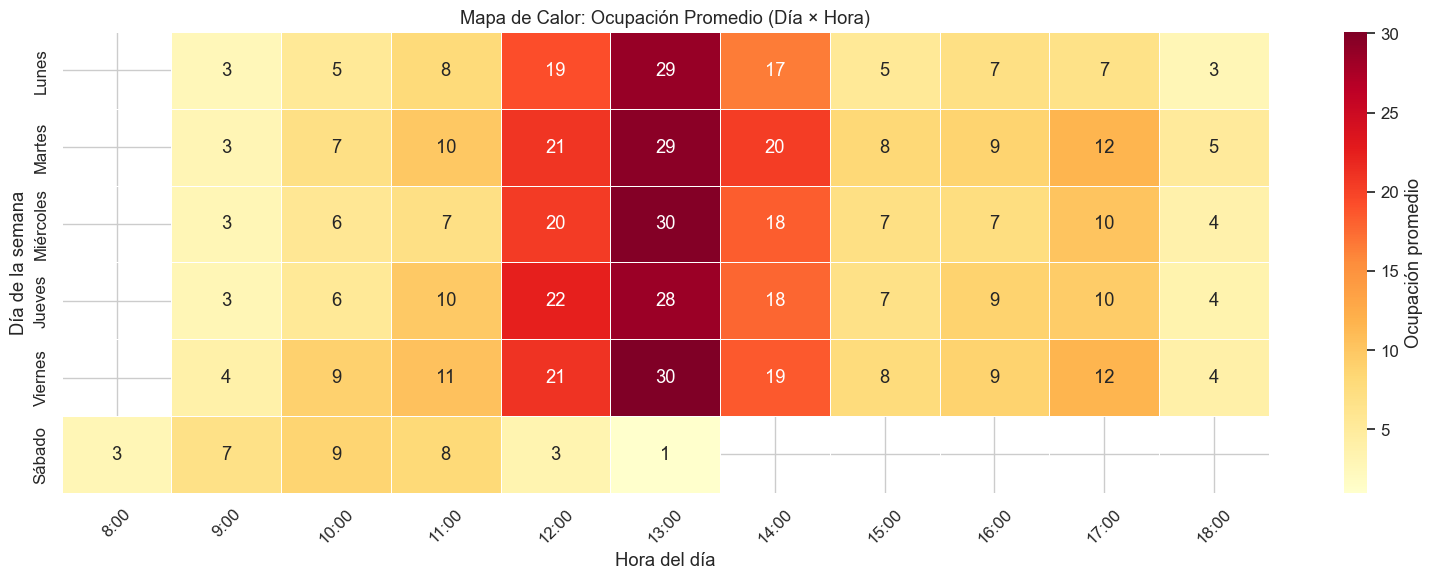


🔴 Top 5 slots MÁS OCUPADOS (evitar):
  Viernes 13:00 → 30 personas promedio
  Miércoles 13:00 → 30 personas promedio
  Martes 13:00 → 29 personas promedio
  Lunes 13:00 → 29 personas promedio
  Jueves 13:00 → 28 personas promedio

🟢 Top 5 slots MENOS OCUPADOS (recomendar):
  Sábado 14:00 → nan personas promedio
  Sábado 15:00 → nan personas promedio
  Sábado 16:00 → nan personas promedio
  Sábado 17:00 → nan personas promedio
  Sábado 18:00 → nan personas promedio


In [51]:
# 5.4  Heatmap: Día × Hora

# Tabla pivote: ocupación promedio por día y hora
heatmap_data = df.pivot_table(
    values='ocupacion',
    index='dia_nombre',
    columns='hora_num',
    aggfunc='mean'
).reindex(orden_dias)

# Renombrar índice a español
heatmap_data.index = [dia_es[d] for d in heatmap_data.index]

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(heatmap_data,
            annot=True, fmt='.0f',
            cmap='YlOrRd',
            cbar_kws={'label': 'Ocupación promedio'},
            linewidths=0.5,
            ax=ax)

ax.set_xlabel('Hora del día')
ax.set_ylabel('Día de la semana')
ax.set_title('Mapa de Calor: Ocupación Promedio (Día × Hora)')
ax.set_xticklabels([f'{int(h)}:00' for h in heatmap_data.columns], rotation=45)

plt.tight_layout()
plt.show()

# Identificar top 5 slots más y menos ocupados
stacked = heatmap_data.stack().reset_index()
stacked.columns = ['Día', 'Hora', 'Ocupación']
stacked = stacked.sort_values('Ocupación', ascending=False)

print('\n🔴 Top 5 slots MÁS OCUPADOS (evitar):')
for _, row in stacked.head(5).iterrows():
    print(f'  {row["Día"]} {int(row["Hora"]):02d}:00 → {row["Ocupación"]:.0f} personas promedio')

print('\n🟢 Top 5 slots MENOS OCUPADOS (recomendar):')
for _, row in stacked.tail(5).iterrows():
    print(f'  {row["Día"]} {int(row["Hora"]):02d}:00 → {row["Ocupación"]:.0f} personas promedio')

**Respuesta a SP 1.2**: Sí, existen diferencias significativas. Los **días entre semana** concentran la mayor actividad, mientras que los **sábados** muestran ~60–70% menos demanda. El heatmap revela los "puntos calientes" exactos (día-hora) que GymTEC debe marcar como alta demanda, y las zonas frías como oportunidades de recomendación. Este mapa puede usarse directamente como tabla de referencia del recomendador de horarios, incluso antes de implementar un modelo sofisticado.

---

### Pregunta 2: ¿Cómo influyen las características demográficas del estudiante en los patrones de uso?

Entender si distintos segmentos de estudiantes usan el gimnasio de manera diferente es clave para personalizar las recomendaciones de GymTEC y evitar diseñar un producto que solo sirva para el segmento mayoritario.

#### Subpregunta 2.1: ¿Hay diferencias en los patrones de asistencia entre géneros?

Comparamos la distribución de ingresos, los patrones horarios y la asistencia por día entre hombres y mujeres.

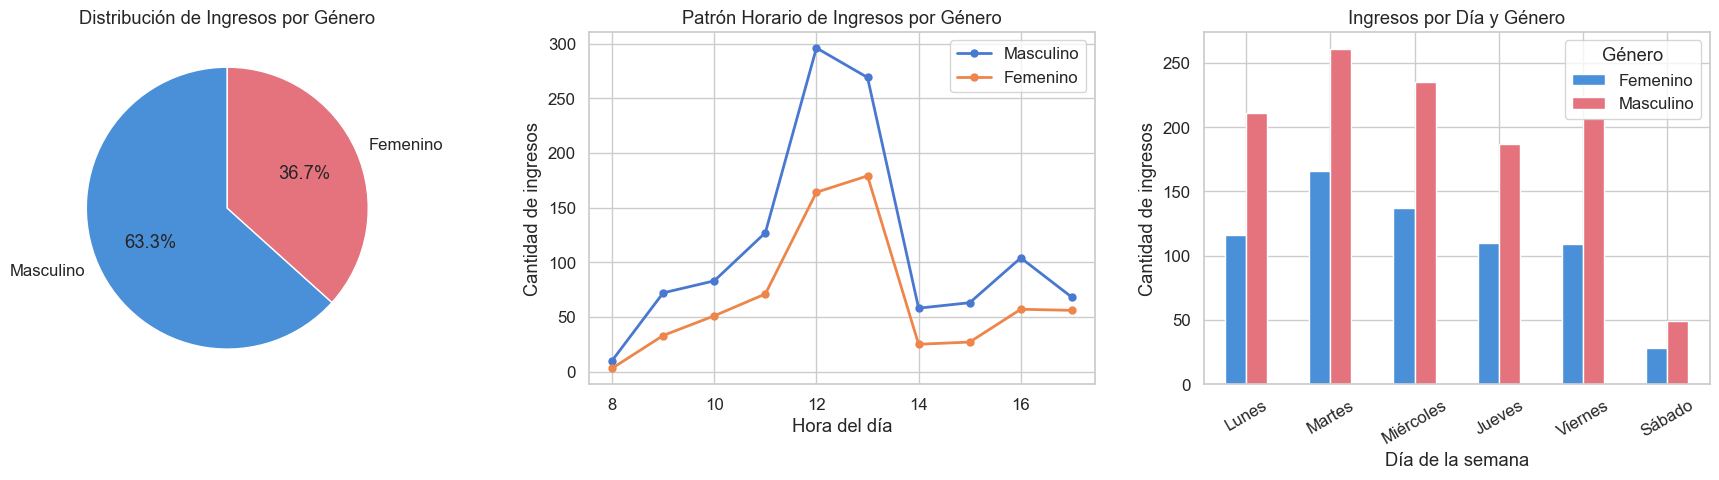


=== Resumen de ingresos por género ===
  Masculino: 1150 ingresos (63.3%)
  Femenino: 666 ingresos (36.7%)


In [52]:
# 5.5  Análisis por género

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# a) Proporción de ingresos por género
genero_counts = df[df['accion'] == 'ingreso']['genero'].value_counts()
colors_gen = ['#4A90D9', '#E5737E']
axes[0].pie(genero_counts.values, labels=genero_counts.index,
            autopct='%1.1f%%', colors=colors_gen, startangle=90)
axes[0].set_title('Distribución de Ingresos por Género')

# b) Patrón horario por género
for genero in ['Masculino', 'Femenino']:
    subset = df[(df['accion'] == 'ingreso') & (df['genero'] == genero)]
    hora_gen = subset.groupby('hora_num').size()
    axes[1].plot(hora_gen.index, hora_gen.values, marker='o', label=genero,
                linewidth=2, markersize=5)

axes[1].set_xlabel('Hora del día')
axes[1].set_ylabel('Cantidad de ingresos')
axes[1].set_title('Patrón Horario de Ingresos por Género')
axes[1].legend()

# c) Distribución por día y género
genero_dia = df[df['accion'] == 'ingreso'].groupby(['dia_nombre', 'genero']).size().unstack(fill_value=0)
genero_dia = genero_dia.reindex(orden_dias)
genero_dia.index = [dia_es[d] for d in genero_dia.index]
genero_dia.plot(kind='bar', ax=axes[2], color=colors_gen, edgecolor='white')
axes[2].set_xlabel('Día de la semana')
axes[2].set_ylabel('Cantidad de ingresos')
axes[2].set_title('Ingresos por Día y Género')
axes[2].tick_params(axis='x', rotation=30)
axes[2].legend(title='Género')

plt.tight_layout()
plt.show()

# Estadísticas de duración de estancia por género
print('\n=== Resumen de ingresos por género ===')
for genero in ['Masculino', 'Femenino']:
    n = genero_counts[genero]
    pct = 100 * n / genero_counts.sum()
    print(f'  {genero}: {n} ingresos ({pct:.1f}%)')

**Respuesta a SP 2.1**: Existe un desbalance en volumen (~63% masculino vs ~37% femenino), pero los **patrones horarios son similares en forma** entre ambos géneros: ambos presentan picos y valles a las mismas horas. Esto sugiere que `genero` puede no aportar mucho al modelo predictivo de ocupación total, aunque sí es útil para personalización en la interfaz de GymTEC.

---

#### Subpregunta 2.2: ¿Qué facultades y carreras lideran el uso del gimnasio?

Analizamos qué segmentos académicos concentran la mayor demanda y si sus patrones horarios difieren entre sí.

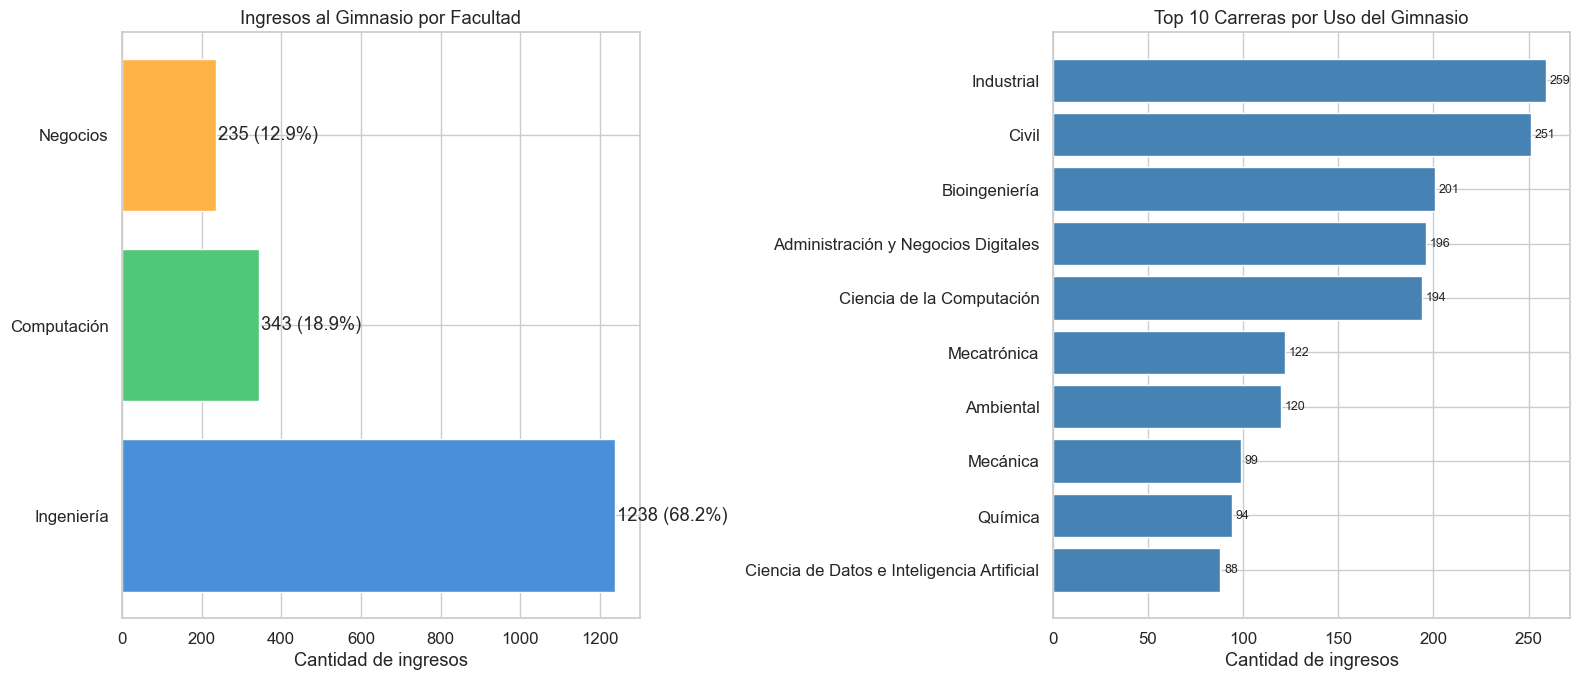

In [53]:
# 5.6  Análisis por facultad y carrera

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# a) Ingresos por facultad
fac_counts = df[df['accion'] == 'ingreso']['facultad'].value_counts()
colors_fac = ['#4A90D9', '#50C878', '#FFB347']
axes[0].barh(fac_counts.index, fac_counts.values, color=colors_fac, edgecolor='white')
axes[0].set_xlabel('Cantidad de ingresos')
axes[0].set_title('Ingresos al Gimnasio por Facultad')
for i, v in enumerate(fac_counts.values):
    axes[0].text(v + 5, i, f'{v} ({100*v/fac_counts.sum():.1f}%)', va='center')

# b) Top 10 carreras con más ingresos
car_counts = df[df['accion'] == 'ingreso']['carrera'].value_counts().head(10)
axes[1].barh(car_counts.index[::-1], car_counts.values[::-1],
             color='steelblue', edgecolor='white')
axes[1].set_xlabel('Cantidad de ingresos')
axes[1].set_title('Top 10 Carreras por Uso del Gimnasio')
for i, v in enumerate(car_counts.values[::-1]):
    axes[1].text(v + 2, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

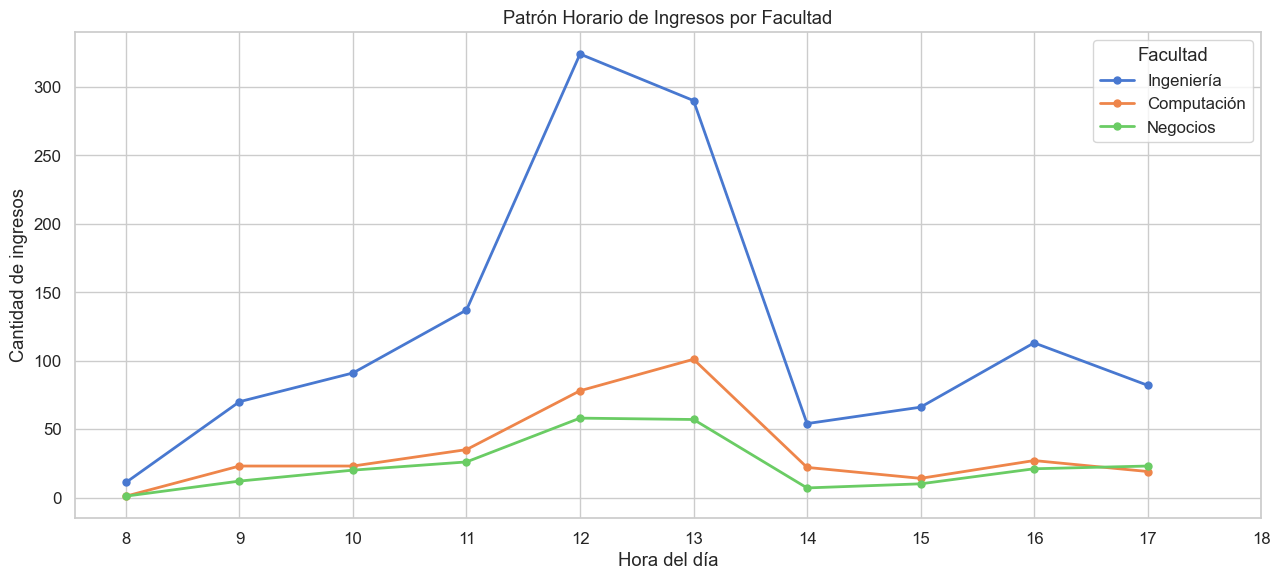

In [54]:
# 5.6b  Patrón horario por facultad
# ¿Las distintas facultades van al gym a horas distintas?
# Si sí, 'facultad' podría ser un feature predictivo útil.

fig, ax = plt.subplots(figsize=(13, 6))

for fac in df['facultad'].unique():
    subset = df[(df['accion'] == 'ingreso') & (df['facultad'] == fac)]
    hora_fac = subset.groupby('hora_num').size()
    ax.plot(hora_fac.index, hora_fac.values, marker='o', label=fac,
            linewidth=2, markersize=5)

ax.set_xlabel('Hora del día')
ax.set_ylabel('Cantidad de ingresos')
ax.set_title('Patrón Horario de Ingresos por Facultad')
ax.legend(title='Facultad')
ax.set_xticks(range(df['hora_num'].min(), df['hora_num'].max() + 1))

plt.tight_layout()
plt.show()

**Respuesta a SP 2.2**: **Ingeniería domina el uso** del gimnasio (~69%), lo cual es coherente con ser la facultad más grande de UTEC. Sin embargo, los **patrones horarios entre facultades son similares** (pico a las mismas horas), lo que indica que `facultad` contribuye más a explicar el volumen total que a diferenciar el timing. Un modelo general sin segmentación excesiva por facultad puede funcionar bien.

---

### Pregunta 3: ¿Cuáles son las tendencias de la demanda y las características de las sesiones de entrenamiento?

Más allá de los patrones cíclicos (hora, día), necesitamos saber si la demanda crece o decrece en el tiempo, y entender cómo se comportan las sesiones individuales. Esto orienta tanto el tipo de modelo a usar como las recomendaciones de GymTEC.

#### Subpregunta 3.1: ¿La demanda muestra una tendencia de crecimiento, decrecimiento o estabilidad durante el periodo observado?

Analizamos la evolución diaria de ingresos y la ocupación máxima diaria para detectar tendencias.

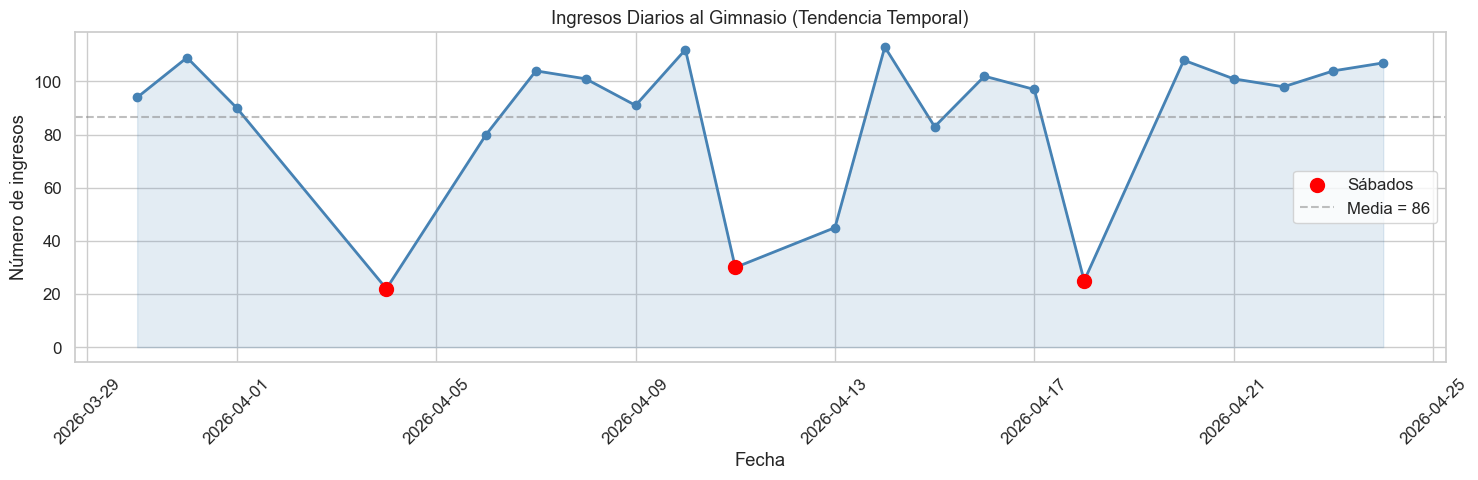


Promedio de ingresos diarios: 86
Día con más ingresos:  Tuesday 14/04 → 113
Día con menos ingresos: Saturday 04/04 → 22


In [55]:
# 5.7  Tendencia temporal: ingresos diarios

ingresos_diarios = (
    df[df['accion'] == 'ingreso']
    .groupby(df['fecha'].dt.date)
    .size()
    .reset_index()
)
ingresos_diarios.columns = ['Fecha', 'Ingresos']
ingresos_diarios['Fecha'] = pd.to_datetime(ingresos_diarios['Fecha'])
ingresos_diarios['Dia'] = ingresos_diarios['Fecha'].dt.day_name()

fig, ax = plt.subplots(figsize=(15, 5))

# Línea de tendencia
ax.plot(ingresos_diarios['Fecha'], ingresos_diarios['Ingresos'],
        marker='o', linewidth=2, color='steelblue', markersize=6)
ax.fill_between(ingresos_diarios['Fecha'], ingresos_diarios['Ingresos'],
                alpha=0.15, color='steelblue')

# Resaltar sábados
sabados = ingresos_diarios[ingresos_diarios['Dia'] == 'Saturday']
ax.scatter(sabados['Fecha'], sabados['Ingresos'],
           color='red', s=100, zorder=5, label='Sábados')

# Media
media = ingresos_diarios['Ingresos'].mean()
ax.axhline(media, color='gray', linestyle='--', alpha=0.5, label=f'Media = {media:.0f}')

ax.set_xlabel('Fecha')
ax.set_ylabel('Número de ingresos')
ax.set_title('Ingresos Diarios al Gimnasio (Tendencia Temporal)')
ax.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print(f'\nPromedio de ingresos diarios: {media:.0f}')
print(f'Día con más ingresos:  {ingresos_diarios.loc[ingresos_diarios["Ingresos"].idxmax(), "Fecha"].strftime("%A %d/%m")} → {ingresos_diarios["Ingresos"].max()}')
print(f'Día con menos ingresos: {ingresos_diarios.loc[ingresos_diarios["Ingresos"].idxmin(), "Fecha"].strftime("%A %d/%m")} → {ingresos_diarios["Ingresos"].min()}')

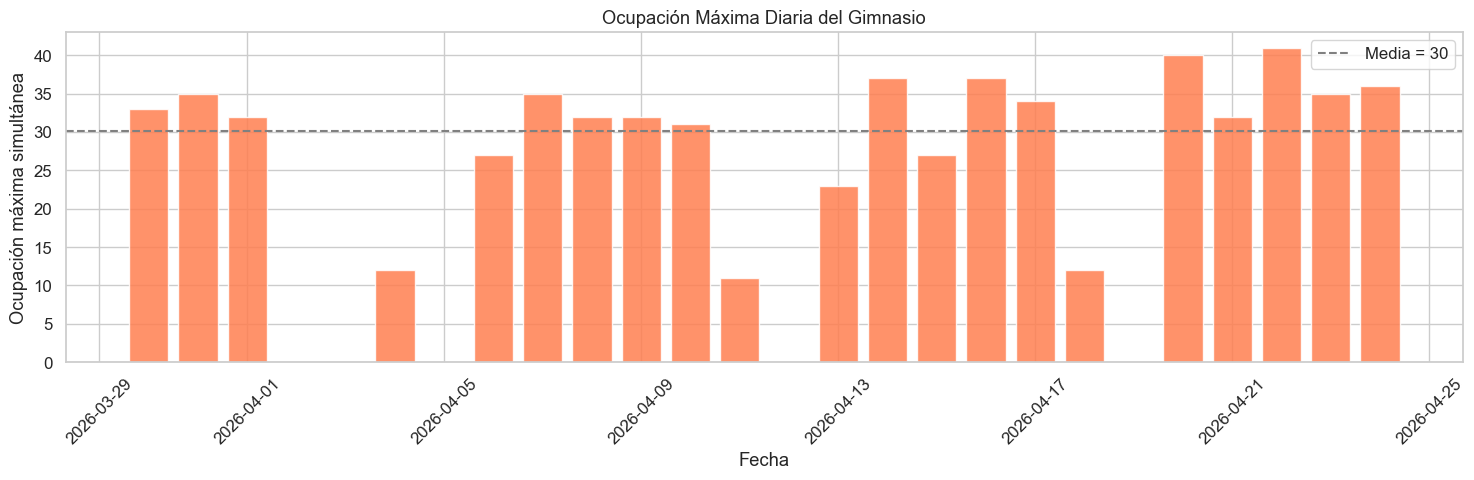

In [56]:
# 5.7b  Evolución de la ocupación máxima diaria

# La ocupación máxima diaria es el pico de personas simultáneas
# que tuvo el gym cada día. Esto es la métrica relevante para
# evaluar si el gym se "satura".

ocu_max_dia = (
    df.groupby(df['fecha'].dt.date)['ocupacion']
    .max()
    .reset_index()
)
ocu_max_dia.columns = ['Fecha', 'Ocupacion_Max']
ocu_max_dia['Fecha'] = pd.to_datetime(ocu_max_dia['Fecha'])

fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(ocu_max_dia['Fecha'], ocu_max_dia['Ocupacion_Max'],
       color='coral', edgecolor='white', alpha=0.85, width=0.8)
ax.axhline(ocu_max_dia['Ocupacion_Max'].mean(), color='gray',
           linestyle='--', label=f'Media = {ocu_max_dia["Ocupacion_Max"].mean():.0f}')

ax.set_xlabel('Fecha')
ax.set_ylabel('Ocupación máxima simultánea')
ax.set_title('Ocupación Máxima Diaria del Gimnasio')
ax.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Respuesta a SP 3.1**: **No hay una tendencia clara de crecimiento o decrecimiento**; la serie es relativamente estable con variaciones cíclicas semanales (sábados bajan). Esto indica que un modelo basado en patrones cíclicos (hora + día) sin componente de tendencia puede ser suficiente. Los sábados (puntos rojos) consistentemente muestran menor actividad, confirmando el hallazgo de la P1.

---

#### Subpregunta 3.2: ¿Cuánto tiempo permanecen los estudiantes y en qué bloques horarios prefieren asistir?

Analizamos la duración típica de las sesiones (impacta cuánto contribuye cada ingreso a la ocupación) y la distribución de demanda por bloque horario (mañana/tarde), que es la granularidad con la que los estudiantes toman decisiones.

Sesiones de entrenamiento (sin outliers): 1816

Duración promedio: 66 minutos
Duración mediana:  67 minutos


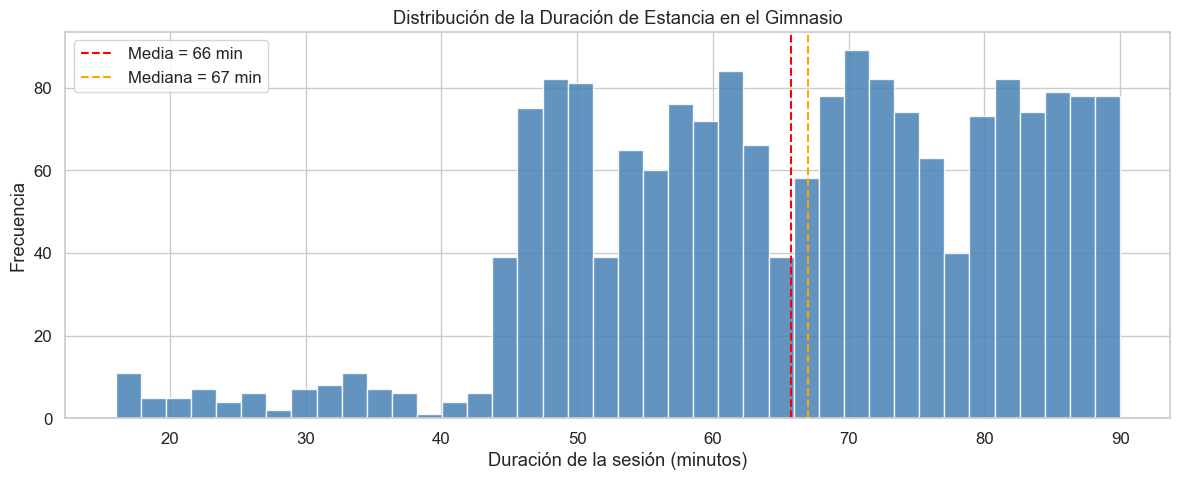

In [57]:
# 5.8  Duración de estancia (sobre el dataset ya limpio de outliers)

# Emparejamos cada ingreso con su salida correspondiente.
# Nota: los outliers (<16 min) ya fueron eliminados en el paso 2.6

ingresos = df[df['accion'] == 'ingreso'][['student_id', 'fecha', 'timestamp']].copy()
ingresos = ingresos.rename(columns={'timestamp': 'ts_ingreso'})

salidas = df[df['accion'] == 'salida'][['student_id', 'fecha', 'timestamp']].copy()
salidas = salidas.rename(columns={'timestamp': 'ts_salida'})

sesiones = ingresos.merge(salidas, on=['student_id', 'fecha'], how='inner')
sesiones['duracion_min'] = (sesiones['ts_salida'] - sesiones['ts_ingreso']).dt.total_seconds() / 60

sesiones_validas = sesiones[sesiones['duracion_min'] > 0]

print(f'Sesiones de entrenamiento (sin outliers): {len(sesiones_validas)}')
print(f'\nDuración promedio: {sesiones_validas["duracion_min"].mean():.0f} minutos')
print(f'Duración mediana:  {sesiones_validas["duracion_min"].median():.0f} minutos')

# Histograma de duración
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(sesiones_validas['duracion_min'], bins=40, color='steelblue',
        edgecolor='white', alpha=0.85)
ax.axvline(sesiones_validas['duracion_min'].mean(), color='red',
           linestyle='--', label=f'Media = {sesiones_validas["duracion_min"].mean():.0f} min')
ax.axvline(sesiones_validas['duracion_min'].median(), color='orange',
           linestyle='--', label=f'Mediana = {sesiones_validas["duracion_min"].median():.0f} min')

ax.set_xlabel('Duración de la sesión (minutos)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de la Duración de Estancia en el Gimnasio')
ax.legend()

plt.tight_layout()
plt.show()

La duración de estancia nos dice cuánto contribuye cada ingreso a la ocupación: si la mayoría dura ~60–90 min, un ingreso a las 12:00 impacta hasta ~13:00–13:30. Ahora veamos la distribución por **bloques horarios** (mañana/tarde).

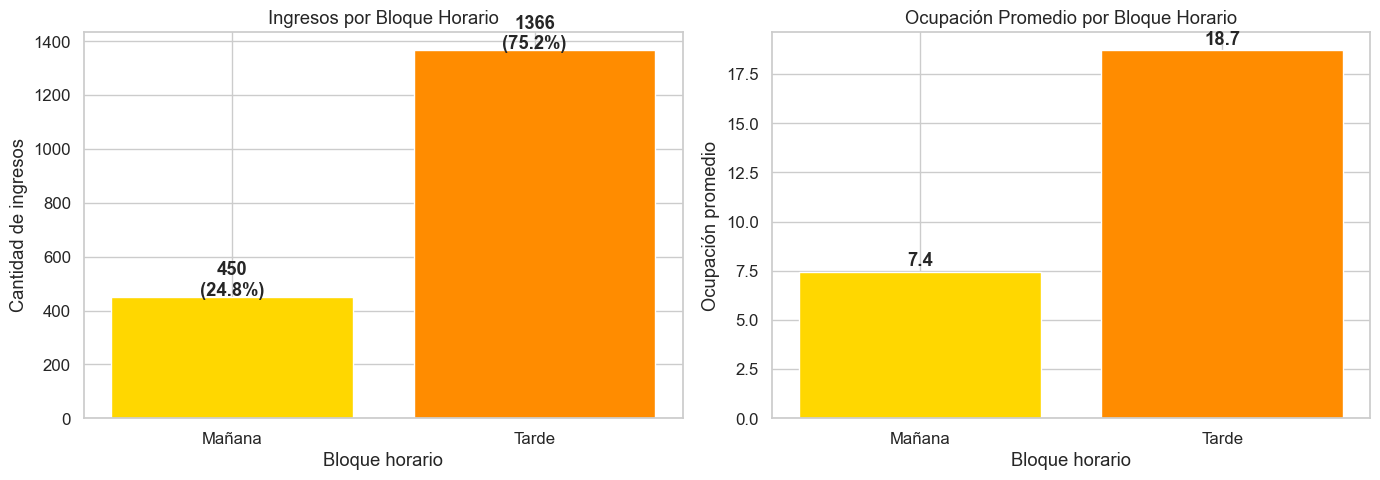

In [58]:
# 5.9  Distribución por bloque horario

bloque_order = ['Mañana', 'Tarde']
colores_bloque = ['#FFD700', '#FF8C00']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# a) Cantidad de ingresos por bloque
bloque_counts = df[df['accion'] == 'ingreso']['bloque_horario'].value_counts().reindex(bloque_order)
axes[0].bar(bloque_order, bloque_counts.values, color=colores_bloque, edgecolor='white')
axes[0].set_xlabel('Bloque horario')
axes[0].set_ylabel('Cantidad de ingresos')
axes[0].set_title('Ingresos por Bloque Horario')
for i, v in enumerate(bloque_counts.values):
    axes[0].text(i, v + 5, f'{v}\n({100*v/bloque_counts.sum():.1f}%)',
                ha='center', fontweight='bold')

# b) Ocupación promedio por bloque
bloque_ocu = df.groupby('bloque_horario')['ocupacion'].mean().reindex(bloque_order)
axes[1].bar(bloque_order, bloque_ocu.values, color=colores_bloque, edgecolor='white')
axes[1].set_xlabel('Bloque horario')
axes[1].set_ylabel('Ocupación promedio')
axes[1].set_title('Ocupación Promedio por Bloque Horario')
for i, v in enumerate(bloque_ocu.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

**Respuesta a SP 3.2**: La **duración típica de sesión es consistente** (distribución concentrada), lo que permite predecir cuándo saldrá un estudiante dado su ingreso. En cuanto a bloques horarios, la **tarde concentra la mayor demanda**, lo que permite a GymTEC priorizar recomendaciones hacia la mañana para estudiantes con flexibilidad. El bloque horario como feature reduce la dimensionalidad respecto a la hora exacta y captura la granularidad de decisión real del estudiante.

---

## 6. Insights y Hallazgos Principales

A partir del análisis descriptivo, extraemos los hallazgos más relevantes para la construcción del data product GymTEC.



In [59]:
# 6.1  Resumen cuantitativo de insights

print('=' * 65)
print('        RESUMEN DE INSIGHTS — GymTEC EDA')
print('=' * 65)

# --- Horas pico ---
top_horas = ocu_por_hora.sort_values('Media', ascending=False).head(3)
print('\n📈 HORAS PICO (mayor ocupación promedio):')
for _, row in top_horas.iterrows():
    print(f'   → {int(row["Hora"]):02d}:00  —  {row["Media"]:.1f} personas (máx: {row["Máximo"]:.0f})')

# --- Horas valle ---
low_horas = ocu_por_hora.sort_values('Media', ascending=True).head(3)
print('\n📉 HORAS VALLE (menor ocupación promedio):')
for _, row in low_horas.iterrows():
    print(f'   → {int(row["Hora"]):02d}:00  —  {row["Media"]:.1f} personas')

# --- Día más ocupado ---
dia_ocu = df.groupby('dia_nombre')['ocupacion'].mean().reindex(orden_dias)
dia_max = dia_ocu.idxmax()
dia_min = dia_ocu.idxmin()
print(f'\n📅 DÍA MÁS OCUPADO:  {dia_es[dia_max]} (promedio: {dia_ocu[dia_max]:.1f})')
print(f'📅 DÍA MENOS OCUPADO: {dia_es[dia_min]} (promedio: {dia_ocu[dia_min]:.1f})')

# --- Duración promedio ---
print(f'\n⏱️  DURACIÓN PROMEDIO DE SESIÓN: {sesiones_validas["duracion_min"].mean():.0f} minutos')

# --- Uso fin de semana vs entre semana ---
ing_semana = df[(df['accion'] == 'ingreso') & (df['es_fin_de_semana'] == 0)].shape[0]
ing_finde = df[(df['accion'] == 'ingreso') & (df['es_fin_de_semana'] == 1)].shape[0]
dias_semana = df[df['es_fin_de_semana'] == 0]['fecha'].dt.date.nunique()
dias_finde = df[df['es_fin_de_semana'] == 1]['fecha'].dt.date.nunique()
print(f'\n🏢 ENTRE SEMANA: {ing_semana/dias_semana:.0f} ingresos/día promedio ({dias_semana} días)')
print(f'🏖️  FIN DE SEMANA: {ing_finde/dias_finde:.0f} ingresos/día promedio ({dias_finde} días)')

# --- Top carreras ---
print(f'\n🎓 TOP 5 CARRERAS POR USO DEL GYM:')
top_carreras = df[df['accion'] == 'ingreso']['carrera'].value_counts().head(5)
for carrera, count in top_carreras.items():
    print(f'   → {carrera}: {count} ingresos')

print('\n' + '=' * 65)

        RESUMEN DE INSIGHTS — GymTEC EDA

📈 HORAS PICO (mayor ocupación promedio):
   → 13:00  —  29.1 personas (máx: 41)
   → 12:00  —  20.4 personas (máx: 35)
   → 14:00  —  18.4 personas (máx: 35)

📉 HORAS VALLE (menor ocupación promedio):
   → 08:00  —  2.9 personas
   → 18:00  —  4.0 personas
   → 09:00  —  4.1 personas

📅 DÍA MÁS OCUPADO:  Martes (promedio: 17.4)
📅 DÍA MENOS OCUPADO: Sábado (promedio: 6.8)

⏱️  DURACIÓN PROMEDIO DE SESIÓN: 66 minutos

🏢 ENTRE SEMANA: 97 ingresos/día promedio (18 días)
🏖️  FIN DE SEMANA: 26 ingresos/día promedio (3 días)

🎓 TOP 5 CARRERAS POR USO DEL GYM:
   → Industrial: 259 ingresos
   → Civil: 251 ingresos
   → Bioingeniería: 201 ingresos
   → Administración y Negocios Digitales: 196 ingresos
   → Ciencia de la Computación: 194 ingresos



### 6.2  Insights clave y su conexión con GymTEC

| # | Insight | Evidencia | Impacto en GymTEC |
|---|---------|-----------|-------------------|
| 1 | **Existe un patrón intradiario claro y consistente** | Gráfico 5.2: distribución de campana con pico bien definido | `hora_num` será el feature más importante del modelo predictivo |
| 2 | **Los sábados tienen ~60-70% menos demanda que entre semana** | Gráfico 5.3 y 5.7: patrón semanal fuerte | `es_fin_de_semana` es un feature binario de alto valor predictivo |
| 3 | **La ocupación tiene horas pico y horas valle bien diferenciadas** | Heatmap 5.4: clusters claros de alta/baja demanda | GymTEC puede recomendar horarios valle con alta confianza |
| 4 | **Los patrones por género son similares en forma** | Gráfico 5.5: las curvas tienen forma similar, difieren en volumen | `genero` puede no aportar mucho al modelo, pero sí a la personalización |
| 5 | **Ingeniería domina el uso, pero el patrón horario es compartido** | Gráfico 5.6: las tres facultades van a las mismas horas | Un modelo general sin segmentar por facultad podría funcionar bien |
| 6 | **La duración típica es consistente** | Gráfico 5.8: distribución concentrada | Un ingreso permite predecir la salida con razonable confianza |
| 7 | **No hay tendencia clara de crecimiento/decrecimiento** | Gráfico 5.7: serie relativamente estable | Un modelo cíclico (sin componente de tendencia) puede ser suficiente |

### 6.3  Recomendaciones para el modelo predictivo

Basado en el EDA, sugerimos:

1. **Features principales**: `hora_num`, `dia_semana`, `es_fin_de_semana`, `bloque_horario`.
2. **Variable target**: `ocupacion_max` por hora (mejor que la media para capturar picos).
3. **Tipo de modelo recomendado**: Modelo de series temporales con estacionalidad diaria y semanal (e.g., SARIMA, Prophet, o un gradient boosting con features temporales).
4. **Validación**: Usar los últimos días como test set (time-based split, nunca random split con datos temporales).
5. **Baseline**: El heatmap día×hora ya sirve como predictor baseline (usar la media histórica).

## 7. Conclusiones

### Resumen del EDA

Este análisis exploratorio del dataset de logs del gimnasio de UTEC nos permite concluir:

1. **Los datos son de alta calidad**: Sin nulos, sin duplicados, con balance perfecto entre ingresos y salidas. Esto simplifica el pipeline pero podría indicar preprocesamiento previo.

2. **Existen patrones temporales fuertes y predecibles**: La ocupación del gimnasio sigue ciclos intradiarios (por hora) y semanales (entre semana vs fin de semana) muy claros. Estos patrones son la base para un modelo predictivo robusto.

3. **Las variables demográficas (género, facultad, carrera) aportan contexto pero no diferenciación temporal significativa**: Los patrones horarios son similares entre segmentos, lo que sugiere que un modelo general sin segmentación excesiva puede funcionar bien.

4. **Las limitaciones son manejables pero reales**: La ventana temporal corta (23 días) es la principal debilidad. El modelo necesitará más datos para capturar estacionalidad académica. Las variables externas (clima, exámenes) serían valiosas en una versión futura.

5. **GymTEC puede funcionar con un enfoque basado en patrones históricos**: Incluso antes de entrenar un modelo sofisticado, el heatmap día×hora ya provee recomendaciones útiles. El modelo añadirá capacidad de predicción en tiempo real y personalización.

### Próximos pasos

- Entrenar modelo predictivo usando los features identificados.
- Implementar sistema de recomendación de horarios basado en predicciones.
- Recopilar más datos (idealmente un ciclo académico completo).
- Incorporar variables externas (calendario académico, clima).
- Validar el modelo con datos futuros (backtesting temporal).